In [273]:
import pandas as pd

df = pd.read_csv("/Users/melina/Downloads/dfforrecom.csv")

print(" Unique values in Decision column:")
print(df['Decision'].dropna().unique())

print("\nValue counts in Decision column:")
for k, v in df['Decision'].value_counts().items():
    print(f"{k}: {v}")


 Unique values in Decision column:
['accepted' 'rejected' 'waitlisted' 'interview' 'other' 'none']

Value counts in Decision column:
accepted: 12184
rejected: 11731
interview: 5014
waitlisted: 4031
other: 1032
none: 1


In [274]:
df = df[~df['Decision'].isin(['other', 'none'])].dropna(subset=['Decision']).copy()


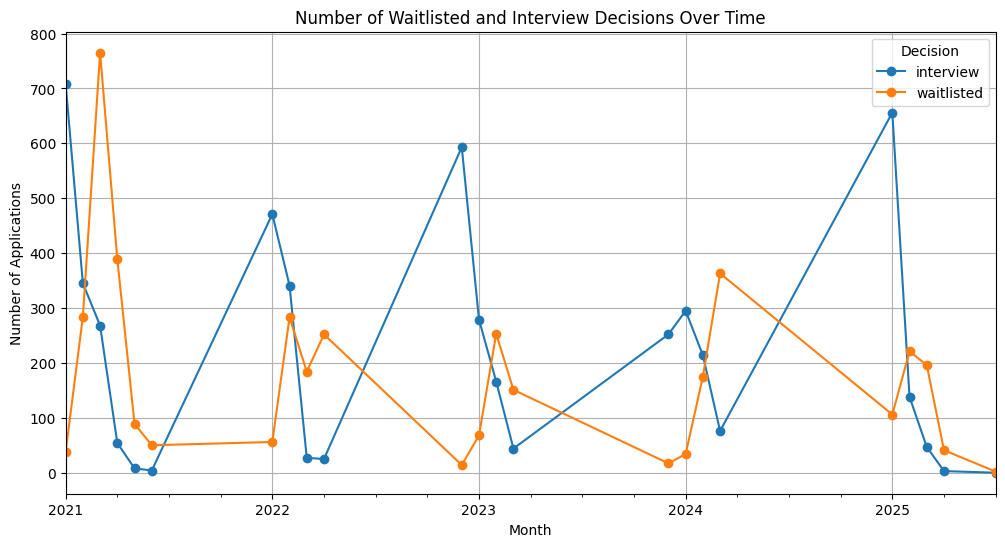

In [275]:
import pandas as pd
import matplotlib.pyplot as plt

df['date_posted'] = pd.to_datetime(df['date_posted'])

df_filtered = df[df['Decision'].isin(['waitlisted', 'interview'])]

time_series = df_filtered.groupby([df_filtered['date_posted'].dt.to_period('M'), 'Decision']).size().unstack(fill_value=0)

time_series.plot(kind='line', marker='o', figsize=(12,6))
plt.title('Number of Waitlisted and Interview Decisions Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.grid(True)
plt.show()


it indicates that the applicants did not update their application result directly after the decisions of waitlisted, interviewed

In [276]:
import pandas as pd
total = len(df)

waitlisted_count = (df['Decision'] == 'waitlisted').sum()
interview_count = (df['Decision'] == 'interview').sum()

combined_count = waitlisted_count + interview_count

waitlisted_pct = (waitlisted_count / total) * 100
interview_pct = (interview_count / total) * 100
combined_pct = (combined_count / total) * 100

print(f"Waitlisted: {waitlisted_count} ({waitlisted_pct:.2f}%)")
print(f"Interview: {interview_count} ({interview_pct:.2f}%)")
print(f" Combined: {combined_count} ({combined_pct:.2f}%)")


Waitlisted: 4031 (12.23%)
Interview: 5014 (15.21%)
 Combined: 9045 (27.44%)


### Decision on Handling *Interviewed* and *Waitlisted* Outcomes  
Even combining the *Waitlisted* (4,031; 12.23%) and *Interview* (5,014; 15.21%) categories into a single intermediate class—together representing 9,045 applicants (27.44%)—would introduce a large secondary class that substantially disrupts class balance and negatively affects baseline model performance. Moreover, these categories do not represent final admission outcomes; applicants rarely update their waitlist or interview status to the actual Accepted or Rejected result. Any manual mapping of these intermediate labels to final decisions would therefore introduce systematic bias and produce unreliable ground-truth targets. For these reasons, the most methodologically sound decision was to remove all records labeled as Waitlisted or Interview and restrict the prediction task to applicants with confirmed final outcomes.


In [277]:
import pandas as pd

df = df[df["Decision"].isin(["accepted", "rejected"])]

df["Decision"] = df["Decision"].map({"accepted": 1, "rejected": 0})

counts = df["Decision"].value_counts()
percentages = df["Decision"].value_counts(normalize=True) * 100

print("Class Counts:")
print(counts)

print("\nClass Percentages:")
print(percentages.round(2))


Class Counts:
Decision
1    12184
0    11731
Name: count, dtype: int64

Class Percentages:
Decision
1    50.95
0    49.05
Name: proportion, dtype: float64


In [278]:

df["SUS RANK"] = df["SUS RANK"].astype(str).str.replace("=", "", regex=False)
df["SUS RANK"] = pd.to_numeric(df["SUS RANK"], errors="coerce")

In [279]:

df['Overall SCORE'] = df['Overall SCORE'].replace('-', pd.NA)

df['Overall SCORE'] = pd.to_numeric(df['Overall SCORE'], errors='coerce')

In [280]:
import pandas as pd
import numpy as np

def convert_rank(rank):
    try:
        rank_str = str(rank).replace('–','-').strip()  
        if '-' in rank_str:
            low, high = rank_str.split('-')
            return (float(low.strip()) + float(high.strip())) / 2
        else:
            return float(rank_str)
    except:
        return np.nan 

df['QS_Rank'] = df['QS_rank'].apply(convert_rank)

df = df.drop(columns=['QS_rank'])



Highly correlated features (corr > 0.85):
AR SCORE  ↔  AR RANK : 0.97
AR SCORE  ↔  ER SCORE : 0.95
AR SCORE  ↔  ER RANK : 0.94
AR SCORE  ↔  Overall SCORE : 0.95
AR RANK  ↔  AR SCORE : 0.97
AR RANK  ↔  ER SCORE : 0.91
AR RANK  ↔  ER RANK : 0.94
AR RANK  ↔  Overall SCORE : 0.90
ER SCORE  ↔  AR SCORE : 0.95
ER SCORE  ↔  AR RANK : 0.91
ER SCORE  ↔  ER RANK : 0.97
ER SCORE  ↔  Overall SCORE : 0.93
ER RANK  ↔  AR SCORE : 0.94
ER RANK  ↔  AR RANK : 0.94
ER RANK  ↔  ER SCORE : 0.97
ER RANK  ↔  Overall SCORE : 0.89
FSR SCORE  ↔  FSR RANK : 0.99
FSR RANK  ↔  FSR SCORE : 0.99
CPF SCORE  ↔  CPF RANK : 0.99
CPF RANK  ↔  CPF SCORE : 0.99
IFR SCORE  ↔  IFR RANK : 0.99
IFR RANK  ↔  IFR SCORE : 0.99
ISR SCORE  ↔  ISR RANK : 0.99
ISR SCORE  ↔  ISD SCORE : 0.95
ISR SCORE  ↔  ISD RANK : 0.96
ISR RANK  ↔  ISR SCORE : 0.99
ISR RANK  ↔  ISD SCORE : 0.95
ISR RANK  ↔  ISD RANK : 0.96
ISD SCORE  ↔  ISR SCORE : 0.95
ISD SCORE  ↔  ISR RANK : 0.95
ISD SCORE  ↔  ISD RANK : 0.99
ISD RANK  ↔  ISR SCORE : 0.96
ISD RAN

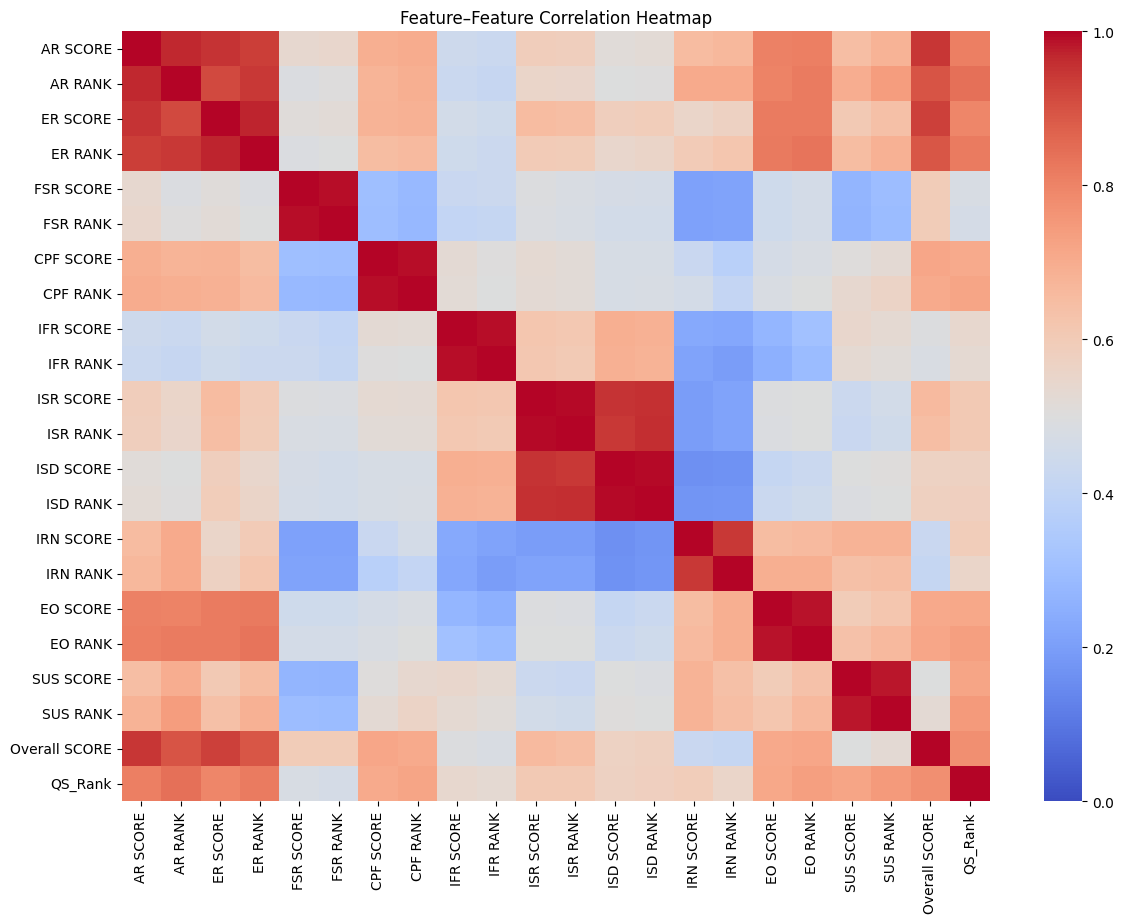

In [281]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = [
    'AR SCORE', 'AR RANK', 'ER SCORE', 'ER RANK',
    'FSR SCORE', 'FSR RANK', 'CPF SCORE', 'CPF RANK',
    'IFR SCORE', 'IFR RANK', 'ISR SCORE', 'ISR RANK',
    'ISD SCORE', 'ISD RANK', 'IRN SCORE', 'IRN RANK',
    'EO SCORE', 'EO RANK', 'SUS SCORE', 'SUS RANK',
    'Overall SCORE', 'QS_Rank'
]

corr_matrix = df[numeric_columns].corr().abs()

upper = corr_matrix.where(~np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, corr_matrix.loc[row, col])
    for col in corr_matrix.columns
    for row in corr_matrix.index
    if (row != col) and (corr_matrix.loc[row, col] > 0.85)
]

print("Highly correlated features (corr > 0.85):")
for pair in high_corr_pairs:
    print(f"{pair[0]}  ↔  {pair[1]} : {pair[2]:.2f}")

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Feature–Feature Correlation Heatmap")
plt.show()


In [282]:
import numpy as np


def group_highly_correlated_features(df, columns, threshold=0.85):
    corr_matrix = df[columns].corr().abs()
    visited = set()
    groups = []

    for col in corr_matrix.columns:
        if col not in visited:
            group = set(corr_matrix.index[corr_matrix[col] > threshold].tolist())
            if len(group) > 1:
                groups.append(group)
            visited |= group

    return groups

groups = group_highly_correlated_features(df, numeric_columns, threshold=0.85)
print(" Correlated feature groups\n")
for i, g in enumerate(groups, 1):
    print(f"Group {i}: {sorted(list(g))}")


 Correlated feature groups

Group 1: ['AR RANK', 'AR SCORE', 'ER RANK', 'ER SCORE', 'Overall SCORE']
Group 2: ['FSR RANK', 'FSR SCORE']
Group 3: ['CPF RANK', 'CPF SCORE']
Group 4: ['IFR RANK', 'IFR SCORE']
Group 5: ['ISD RANK', 'ISD SCORE', 'ISR RANK', 'ISR SCORE']
Group 6: ['IRN RANK', 'IRN SCORE']
Group 7: ['EO RANK', 'EO SCORE']
Group 8: ['SUS RANK', 'SUS SCORE']



Pearson correlation with accepted:
 accepted_bin     1.000000
FSR SCORE        0.149131
Overall SCORE    0.144739
AR SCORE         0.127011
CPF SCORE        0.117996
ER SCORE         0.107236
EO SCORE         0.105585
IFR SCORE        0.069245
SUS SCORE        0.056335
ISR SCORE        0.056324
ISD SCORE        0.045518
IRN SCORE        0.042716
IRN RANK        -0.034366
ISD RANK        -0.048032
ISR RANK        -0.055130
IFR RANK        -0.059586
SUS RANK        -0.063441
QS_Rank         -0.101435
ER RANK         -0.106761
EO RANK         -0.110315
CPF RANK        -0.117905
AR RANK         -0.124433
FSR RANK        -0.149727
Name: accepted_bin, dtype: float64



Mutual Information with accepted:
 EO RANK          0.040540
SUS SCORE        0.039818
ISR SCORE        0.038864
QS_Rank          0.038754
AR RANK          0.036756
ISD RANK         0.035974
IRN RANK         0.035864
SUS RANK         0.035634
ER RANK          0.035449
CPF SCORE        0.035011
ISR RANK         0.034851
CPF RANK         0.034805
IFR RANK         0.034128
ISD SCORE        0.033903
FSR RANK         0.033126
IRN SCORE        0.033097
Overall SCORE    0.031664
IFR SCORE        0.031597
EO SCORE         0.030511
ER SCORE         0.026428
FSR SCORE        0.025671
AR SCORE         0.025561
dtype: float64

Random Forest Feature Importance (accepted only):
 CPF RANK         0.079780
FSR SCORE        0.073322
Overall SCORE    0.069894
FSR RANK         0.064293
CPF SCORE        0.056234
QS_Rank          0.053654
ISR SCORE        0.051732
ER RANK          0.048398
ISR RANK         0.048054
AR RANK          0.047064
EO RANK          0.039888
AR SCORE         0.039533
EO SCORE     

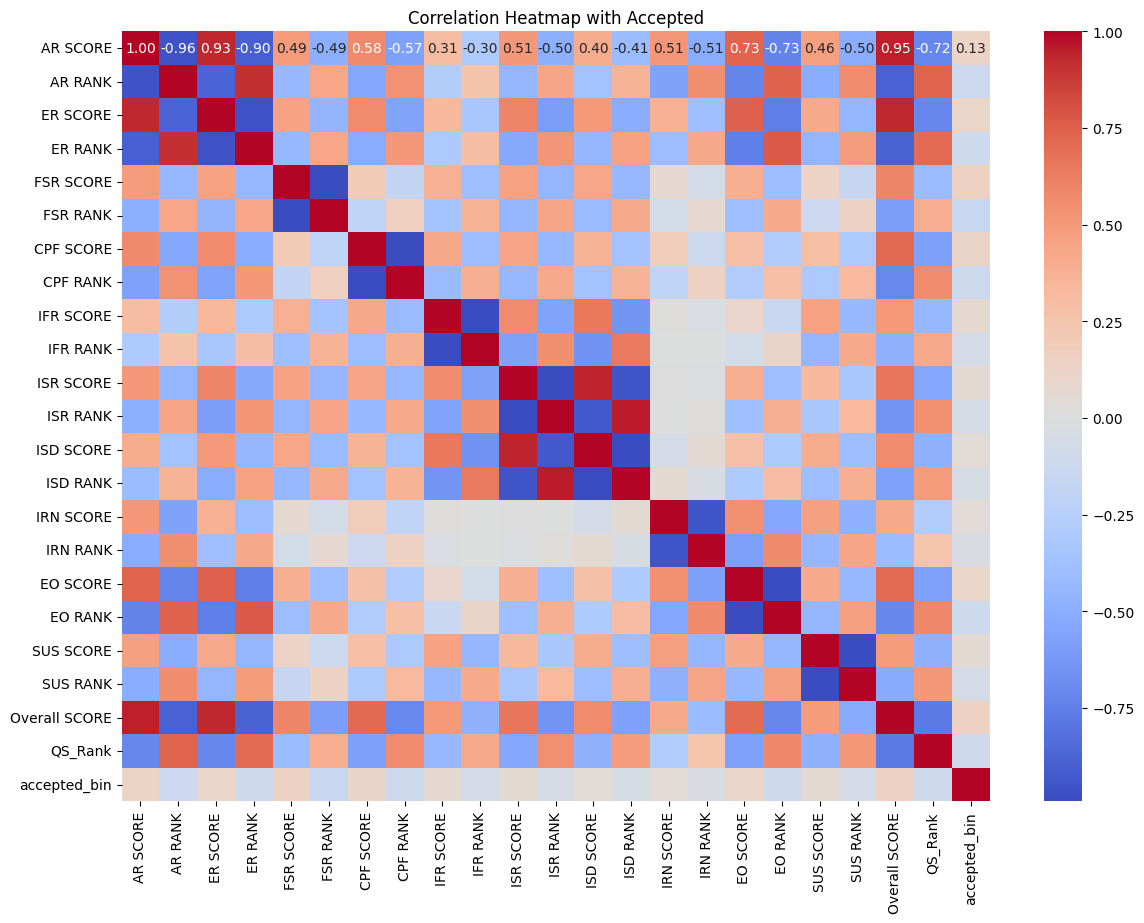

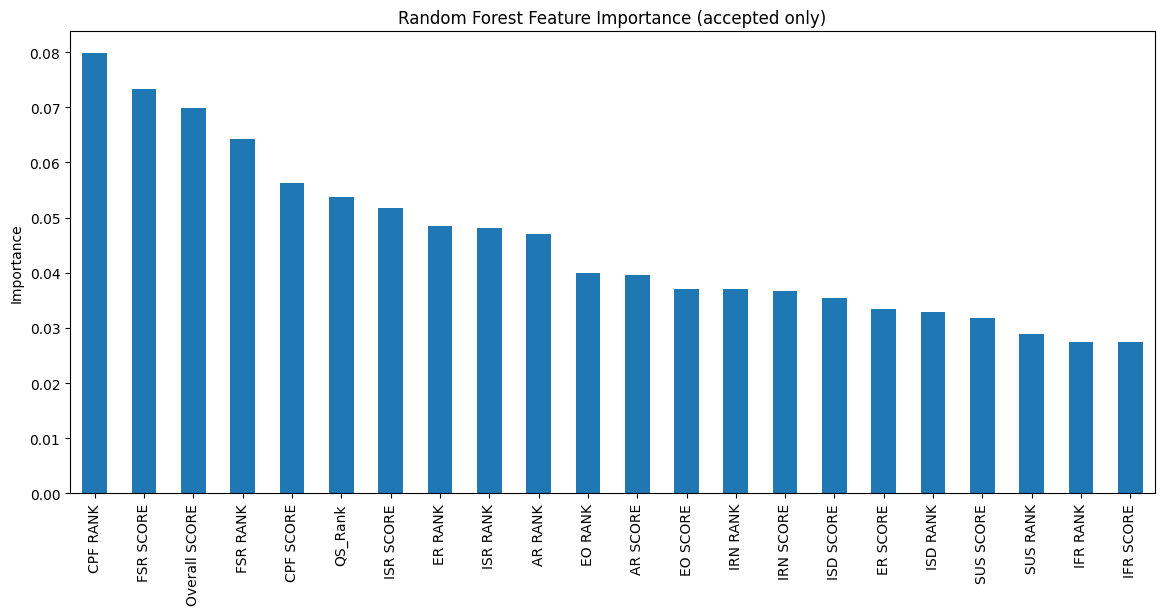

In [283]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = [
    'AR SCORE', 'AR RANK', 'ER SCORE', 'ER RANK',
    'FSR SCORE', 'FSR RANK', 'CPF SCORE', 'CPF RANK',
    'IFR SCORE', 'IFR RANK', 'ISR SCORE', 'ISR RANK',
    'ISD SCORE', 'ISD RANK', 'IRN SCORE', 'IRN RANK',
    'EO SCORE', 'EO RANK', 'SUS SCORE', 'SUS RANK',
    'Overall SCORE', 'QS_Rank'
]

df['accepted_bin'] = (df['Decision'] == 0).astype(int)

cols_to_corr = numeric_columns + ['accepted_bin']
corr_df = df[cols_to_corr].dropna()
corr = corr_df.corr()['accepted_bin'].sort_values(ascending=False)
print("\nPearson correlation with accepted:\n", corr)


X_mi = df[numeric_columns].copy()
y = df['accepted_bin']

mi_df = pd.concat([X_mi, y], axis=1).dropna()
X_mi_clean = mi_df[X_mi.columns]
y_clean = mi_df['accepted_bin']

mi_scores = mutual_info_classif(X_mi_clean, y_clean, discrete_features=False, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)
print("\nMutual Information with accepted:\n", mi_scores)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_mi_clean, y_clean)
importances = pd.Series(rf.feature_importances_, index=X_mi.columns).sort_values(ascending=False)
print("\nRandom Forest Feature Importance (accepted only):\n", importances)

plt.figure(figsize=(14,10))
sns.heatmap(df[numeric_columns + ['accepted_bin']].dropna().corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap with Accepted")
plt.show()
plt.figure(figsize=(14,6))
importances.plot(kind='bar', title="Random Forest Feature Importance (accepted only)")
plt.ylabel("Importance")
plt.show()


For accepted applications, the most important features are FSR SCORE, CPF SCORE, ISR SCORE, and Overall SCORE, with QS_Rank also moderately influencing acceptance due to university selectivity. Other scores have less impact. Pearson correlations are weak, showing higher scores slightly favor acceptance, while Mutual Information and Random Forest analyses capture non-linear effects and interactions, confirming that the top SCORE features dominate and QS_Rank has moderate importance.

In [284]:
important_cols = ['FSR SCORE', 'CPF SCORE', 'ISR SCORE', 'Overall SCORE', 'QS_Rank']

redundant_cols = [col for col in numeric_columns if col not in important_cols]
df.drop(columns=redundant_cols, inplace=True)


In [285]:

nan_percentage = df[['GPA', 'GRE_V', 'GRE_AW', 'GRE_Total']].isna().mean() * 100
print("Percentage of NaNs per column:\n", nan_percentage)

all_nan_percentage = df[['GPA', 'GRE_V', 'GRE_AW', 'GRE_Total']].isna().all(axis=1).mean() * 100
print(f"\nPercentage of rows where all four columns are NaN: {all_nan_percentage:.2f}%")

all_complete_percentage = df[['GPA', 'GRE_V', 'GRE_AW', 'GRE_Total']].notna().all(axis=1).mean() * 100
print(f"Percentage of rows where all four columns are complete: {all_complete_percentage:.2f}%")

gpa_gre_present_percentage = df[['GPA', 'GRE_Total']].notna().all(axis=1).mean() * 100
print(f"Percentage of rows where both GPA and GRE_Total are present: {gpa_gre_present_percentage:.2f}%")


Percentage of NaNs per column:
 GPA          52.912398
GRE_V        87.100146
GRE_AW       87.865356
GRE_Total    86.560736
dtype: float64

Percentage of rows where all four columns are NaN: 51.33%
Percentage of rows where all four columns are complete: 9.94%
Percentage of rows where both GPA and GRE_Total are present: 12.00%


The dataset shows substantial missing data in key academic features: GPA is missing in 58.7% of rows, GRE components in approximately 89%, and all four features are missing in 57.4% of rows. Only 8.3% of rows have all features complete, and just 10.1% have both GPA and GRE_Total present.

In [286]:

rows_gpa_gre_present = df[['GPA', 'GRE_Total']].notna().all(axis=1).sum()

total_rows = len(df)

percentage_present = (rows_gpa_gre_present / total_rows) * 100

print(f"Number of rows where both GPA and GRE_Total are present: {rows_gpa_gre_present}")


Number of rows where both GPA and GRE_Total are present: 2869


GPA completeness percentage per year:
 year_posted
2021    33.060842
2022    54.316239
2023    39.273927
2024    60.820114
2025    57.089625
Name: GPA, dtype: float64


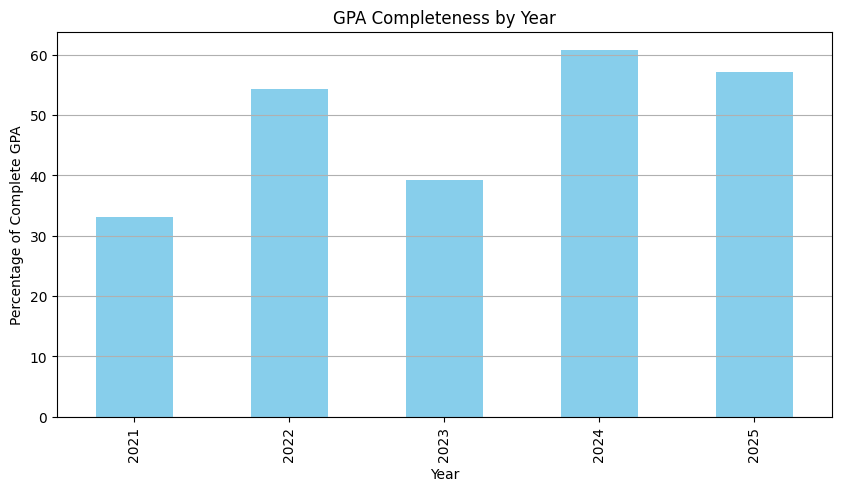

In [287]:
import matplotlib.pyplot as plt

df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')

df['year_posted'] = df['date_posted'].dt.year

gpa_completeness_by_year = df.groupby('year_posted')['GPA'].apply(lambda x: x.notna().mean() * 100)
print("GPA completeness percentage per year:\n", gpa_completeness_by_year)
plt.figure(figsize=(10,5))
gpa_completeness_by_year.plot(kind='bar', color='skyblue')
plt.ylabel("Percentage of Complete GPA")
plt.xlabel("Year")
plt.title("GPA Completeness by Year")
plt.grid(axis='y')
plt.show()


Number of rows per country:
 Country/Territory
United States of America    19966
Canada                       1336
United Kingdom               1002
Switzerland                   261
Spain                         130
                            ...  
Jordan                          1
Oman                            1
Tunisia                         1
Ghana                           1
Israel                          1
Name: count, Length: 64, dtype: int64

Top 20 countries by row count with GPA presence percentage:
                           row_count  GPA_present_percent
Country/Territory                                       
United States of America      19966            47.285385
Canada                         1336            46.631737
United Kingdom                 1002            38.722555
Switzerland                     261            50.191571
Spain                           130            47.692308
Germany                         128            49.218750
Australia              

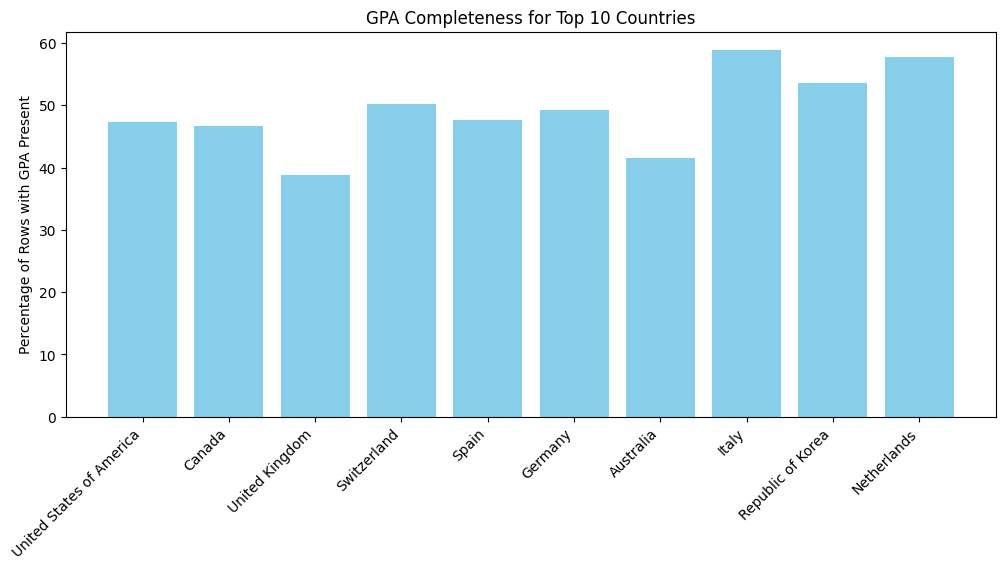

In [288]:
import pandas as pd
import matplotlib.pyplot as plt

df['GPA_present'] = df['GPA'].notna()

country_counts = df['Country/Territory'].value_counts()
print("Number of rows per country:\n", country_counts)

gpa_percent_by_country = df.groupby('Country/Territory')['GPA_present'].mean() * 100

country_bias_df = pd.DataFrame({
    'row_count': country_counts,
    'GPA_present_percent': gpa_percent_by_country
}).sort_values(by='row_count', ascending=False)

print("\nTop 20 countries by row count with GPA presence percentage:\n", country_bias_df.head(20))

top_countries = country_bias_df.head(10) 

plt.figure(figsize=(12,5))
plt.bar(top_countries.index, top_countries['GPA_present_percent'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Percentage of Rows with GPA Present")
plt.title("GPA Completeness for Top 10 Countries")
plt.show()


📊 GPA Descriptive Statistics:
count    11261.000000
mean         3.798919
std          0.600579
min          1.100000
25%          3.610000
50%          3.800000
75%          3.930000
max          9.990000
Name: GPA, dtype: float64

Additional Statistics:
Variance: 0.361
Standard Deviation: 0.601
Skewness: 7.201
Kurtosis: 64.582


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


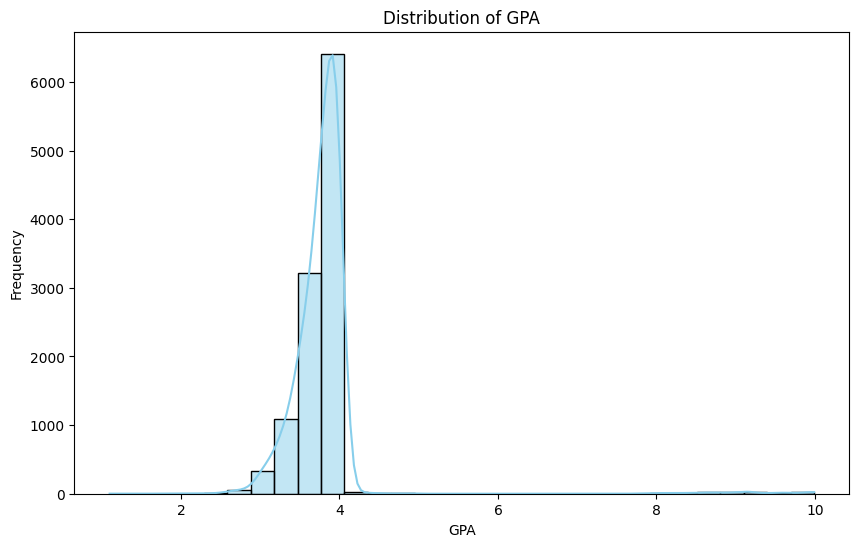

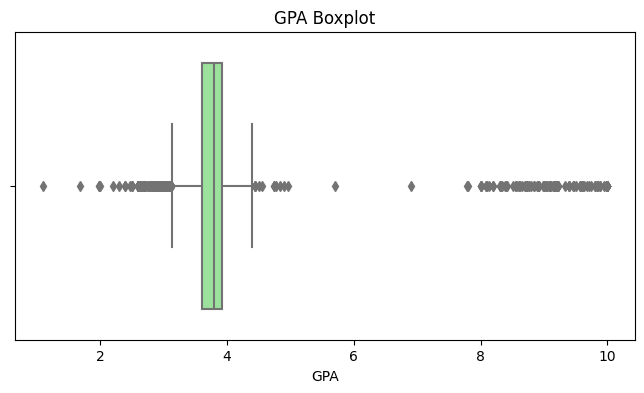

In [289]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gpa_data = df['GPA'].dropna()

print("📊 GPA Descriptive Statistics:")
print(gpa_data.describe())

print("\nAdditional Statistics:")
print(f"Variance: {gpa_data.var():.3f}")
print(f"Standard Deviation: {gpa_data.std():.3f}")
print(f"Skewness: {gpa_data.skew():.3f}")
print(f"Kurtosis: {gpa_data.kurtosis():.3f}")

plt.figure(figsize=(10,6))
sns.histplot(gpa_data, bins=30, kde=True, color='skyblue')
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=gpa_data, color='lightgreen')
plt.title("GPA Boxplot")
plt.xlabel("GPA")
plt.show()


In [290]:

unique_words = set(" ".join(df['cleaned_degree'].dropna()).split())

print("Unique words in cleaned_degree:\n", unique_words)


Unique words in cleaned_degree:
 {'Psyd', 'Phd', 'Edd', 'Jd', 'Masters', 'Other', 'Ind', 'Mfa', 'Mba'}


In [291]:

degree_counts = df['cleaned_degree'].value_counts()

degree_percentage = (degree_counts / len(df)) * 100

print("Percentage of each cleaned_degree:\n", degree_percentage)


Percentage of each cleaned_degree:
 cleaned_degree
Phd        64.424002
Masters    30.980556
Mfa         2.533974
Psyd        1.011917
Other       0.928288
Edd         0.071085
Mba         0.029270
Jd          0.012544
Ind         0.008363
Name: count, dtype: float64


In [292]:

df = df[df['cleaned_degree'].isin(['Phd', 'Masters'])].copy()

print(df['cleaned_degree'].value_counts(normalize=True) * 100)


cleaned_degree
Phd        67.527174
Masters    32.472826
Name: proportion, dtype: float64


We excluded all degrees other than PhD and Masters (such as MFA, Psyd, MBA, JD, Edd, Ind, and Other) because they collectively account for only ~4.85% of the dataset. This ensures the analysis focuses on the majority of graduate applications while reducing noise from very small groups.

In [293]:

df['GPA_present'] = df['GPA'].notna()
df['GRE_Total_present'] = df['GRE_Total'].notna()

completeness = df.groupby('cleaned_degree')[['GPA_present', 'GRE_Total_present']].mean() * 100

print("GPA and GRE_Total completeness (%) by degree:\n", completeness)


GPA and GRE_Total completeness (%) by degree:
                 GPA_present  GRE_Total_present
cleaned_degree                                
Masters           59.130787          18.976920
Phd               42.175634          11.462322


GPA is the key academic indicator, while GRE scores are largely missing—only 18% of Master’s and 11% of PhD rows with complete GPA have GRE_Total. Imputing GRE would risk bias, so we decide to drop all GRE-related features. Also GPA compeletness in not biased through certain countries,years or degree types as we checked and therefore it would support our decsion on randomley imputing 10% of missing gpa.

In [294]:
import pandas as pd
df = df.drop(columns=["GRE_AW", "GRE_V", "GRE_Total"])


In [295]:

df['GPA_missing'] = ~df['GPA_present']

gpa_missing_counts = df.groupby('cleaned_degree')['GPA_missing'].sum()

gpa_missing_pct = (gpa_missing_counts / gpa_missing_counts.sum()) * 100

print("Percentage of missing GPA rows by degree:\n", gpa_missing_pct)


Percentage of missing GPA rows by degree:
 cleaned_degree
Masters    25.366507
Phd        74.633493
Name: GPA_missing, dtype: float64


In [296]:

master_rows = (df['cleaned_degree'] == 'Masters').sum()
print(f"Number of rows dedicated to Masters: {master_rows}")

master_gpa_present = df[(df['cleaned_degree'] == 'Masters') & (df['GPA_present'])].shape[0]
print(f"Number of Masters rows with GPA present: {master_gpa_present}")


Number of rows dedicated to Masters: 7409
Number of Masters rows with GPA present: 4381


In [297]:
import pandas as pd
import re

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[\:\=\-\+\/]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

ielts_pattern = re.compile(r'(?i)\bielts\b\s*(?:band|score|overall)?\s*(\d(?:\.\d)?)')
typo_pattern = re.compile(r'(?i)(?:ielt[sz]?|iles|ieltz|ielst|ielt)\s*(?:band|score|overall)?\s*(\d(?:\.\d)?)')

def smart_fallback(text):
    keywords = ['ielts', 'band', 'score', 'overall', 'english', 'academic']
    for kw in keywords:
        for match in re.finditer(rf'({kw})\s*(\d(?:\.\d)?)', text):
            try:
                val = float(match.group(2))
                if 4.0 <= val <= 9.0:
                    return val
            except:
                continue
    return None

def extract_ielts(text):
    if pd.isna(text):
        return None
    text = normalize_text(text)
    for pat in [ielts_pattern, typo_pattern]:
        match = pat.search(text)
        if match:
            for g in match.groups():
                if g:
                    try:
                        return float(g)
                    except:
                        pass
    return smart_fallback(text)

df['IELTS_score'] = df['notes_raw'].apply(extract_ielts)

matched_percentage = df['IELTS_score'].notna().mean() * 100
print(f"Percentage of rows with IELTS score matched: {matched_percentage:.2f}%")


Percentage of rows with IELTS score matched: 0.25%


In [298]:

degree_levels = ['Masters', 'Phd']  


for degree in degree_levels:
    subset = df[df['cleaned_degree'] == degree]
    if len(subset) == 0:
        print(f"No rows found for {degree}")
    else:
        matched_percentage = subset['IELTS_score'].notna().sum() / len(subset) * 100
        print(f"Percentage of rows with IELTS score for {degree}: {matched_percentage:.2f}%")


Percentage of rows with IELTS score for Masters: 0.34%
Percentage of rows with IELTS score for Phd: 0.21%


In [299]:
for degree in ['Masters', 'Phd']:
    subset = df[df['cleaned_degree'] == degree]
    total_rows = len(subset)
    print(f"\nDegree: {degree}")
    print(f"Total rows: {total_rows}")
    gpa_true_count = subset[subset['GPA_present'] == True].shape[0]
    print(f"GPA_present=True rows: {gpa_true_count}")
    ielts_present_count = subset[subset['IELTS_score'].notna()].shape[0]
    print(f"IELTS_score not NaN rows: {ielts_present_count}")
    both_count = subset[(subset['GPA_present'] == True) & (subset['IELTS_score'].notna())].shape[0]
    print(f"Both GPA_present=True and IELTS_score present: {both_count}")
    percentage = (both_count / total_rows) * 100 if total_rows > 0 else 0
    print(f"Percentage: {percentage:.2f}%")



Degree: Masters
Total rows: 7409
GPA_present=True rows: 4381
IELTS_score not NaN rows: 25
Both GPA_present=True and IELTS_score present: 23
Percentage: 0.31%

Degree: Phd
Total rows: 15407
GPA_present=True rows: 6498
IELTS_score not NaN rows: 32
Both GPA_present=True and IELTS_score present: 27
Percentage: 0.18%


For Master’s (7,409 rows) and PhD (15,407 rows) applications, very few applicants report IELTS scores—only 23 (0.31%) and 27 (0.18%) rows, respectively, have both GPA and IELTS present. Due to these extremely low percentages, creating a separate IELTS column from notes is not recommended, and the note column is therefore unlikely to provide valuable information and can be dropped.

In [300]:
import pandas as pd

df = df.drop(columns=["notes_raw", "IELTS_score"])


In [301]:

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean().sort_values(ascending=False) * 100)
missing_report = pd.concat([missing_counts, missing_pct], axis=1)
missing_report.columns = ['missing_count', 'missing_percent']
missing_report.head(60) 


,missing_count,missing_percent
GPA,11937,52.318548
cleaned_status,2353,10.312938
Overall SCORE,2123,9.304874
ISR SCORE,136,0.596073
Status,53,0.232293
match_score,27,0.118338
CPF SCORE,27,0.118338
FSR SCORE,27,0.118338
Research,27,0.118338
Region,27,0.118338


Encoding categorical variables

In [302]:

num_unique = df["university_qs_matched"].nunique()
print("Number of unique universities:", num_unique)

Number of unique universities: 469


In [303]:
df = df.dropna(subset=['university_qs_matched']).copy()

In [304]:
df = df.drop(columns=['Decision_num'], errors='ignore')


encoding categprical variables 

In [305]:
import pandas as pd

df_gpa_present = df[df['GPA_present'] == True]

discipline_percent_gpa = df_gpa_present['Target_Program_Discipline'].value_counts(normalize=True) * 100

print("Target_Program_Discipline distribution in percentage for rows with GPA present (top 10):")
print(discipline_percent_gpa.head(10))


Target_Program_Discipline distribution in percentage for rows with GPA present (top 10):
Target_Program_Discipline
social science           9.973343
physical sciences        9.440206
engineering              9.182829
computer science         9.182829
science                  6.434415
pathology                4.476514
philosophy               3.860649
psychology               3.419432
natural science          3.162055
Geisteswissenschaften    2.831143
Name: proportion, dtype: float64


In [306]:
import pandas as pd

df_gpa_present = df[df['GPA_present'] == True]

university_percent_gpa = df_gpa_present['university_qs_matched'].value_counts(normalize=True) * 100

print("University distribution in percentage for rows with GPA present (top 10):")
print(university_percent_gpa.head(10))


University distribution in percentage for rows with GPA present (top 10):
university_qs_matched
california technology caltech    4.577627
washington                       3.189631
stanford                         2.969023
michigan                         2.867911
wisconsin madison                2.555382
pennsylvania                     2.426694
chicago                          2.242853
columbia                         2.206085
massachusetts technology mit     1.985477
cornell                          1.967093
Name: proportion, dtype: float64


In [307]:
import pandas as pd

df_gpa_present = df[df['GPA_present'] == True]

country_percent_gpa = df_gpa_present['Country/Territory'].value_counts(normalize=True) * 100

print("Country/Territory distribution in percentage for rows with GPA present (top 10):")
print(country_percent_gpa.head(10))


Country/Territory distribution in percentage for rows with GPA present (top 10):
Country/Territory
United States of America    84.301630
Canada                       5.570389
United Kingdom               3.452721
Switzerland                  1.187736
Germany                      0.561643
Italy                        0.524814
Spain                        0.497192
Australia                    0.451156
Republic of Korea            0.423534
Netherlands                  0.340668
Name: proportion, dtype: float64


Based on the distributions, most columns show no extreme dominance except for Country/Territory, where the United States accounts for 84% of rows with GPA present. Programs, disciplines, and universities remain more evenly distributed. Therefore, frequency encoding is recommended for Program, Target_Program_Discipline, university_qs_matched, and Country/Territory, as it efficiently captures relative representation while avoiding sparsity.

In [308]:

unique_universities = sorted(df["university_qs_matched"].unique())

num_universities = len(unique_universities)
print(f"Total unique universities: {num_universities}\n")

for i, uni in enumerate(unique_universities, start=1):
    print(f"{i}. {uni}")


Total unique universities: 469

1. #0897Village University
2. Faulkner University
3. Fletcher School Of Law And Diplomacy
4. IMPRS QST
5. JHU SAIS
6. Max Planck School
7. Maxwell School Of Citizenship And Public Affairs
8. Mayo Clinic
9. NSF GRFP
10. NYU Sackler
11. OnlyFans College
12. Pulchowk Campus
13. Roosevelt University
14. St. Ambrose University
15. University Of
16. University Of School
17. WUSTL, UIUC
18. Wesleyan University
19. aalto
20. aarhus
21. aberdeen
22. abo akademi
23. ada
24. adelaide
25. ajman
26. al ain
27. alabama
28. alaska fairbanks
29. albany suny
30. alberta
31. alma mater studiorum bologna
32. american
33. american sharjah aus
34. amsterdam
35. anna
36. arizona
37. arkansas fayetteville
38. aston
39. athens economics business
40. auburn
41. auckland
42. australian
43. balamand
44. bangladesh engineering technology
45. barcelona
46. bari
47. bath
48. baylor
49. beihang former buaa
50. beijing chinese medicine
51. belgorod
52. bergen
53. bern
54. binghamton su

In [309]:
import pandas as pd

university_correction_map = {
    "california technology": "California Institute of Technology",
    "california technology caltech": "California Institute of Technology",
    "san diego": "University of California, San Diego",
    "california san diego ucsd": "University of California, San Diego",
    "north carolina": "University of North Carolina at Chapel Hill",
    "north carolina chapel hill": "University of North Carolina at Chapel Hill",

    "alabama": "University of Alabama",
    "alberta": "University of Alberta",
    "american": "American University",
    "arizona": "University of Arizona",
    "auburn": "Auburn University",
    "balamand": "University of Balamand",
    "boston": "Boston University",
    "brandeis": "Brandeis University",
    "british columbia": "University of British Columbia",
    "brown": "Brown University",
    "buffalo suny": "University at Buffalo, SUNY",
    "calgary": "University of Calgary",
    "california berkeley ucb": "University of California, Berkeley",
    "california irvine": "University of California, Irvine",
    "california riverside": "University of California, Riverside",
    "california santa barbara ucsb": "University of California, Santa Barbara",
    "cambridge": "University of Cambridge",
    "carnegie mellon": "Carnegie Mellon University",
    "case western reserve": "Case Western Reserve University",
    "central florida": "University of Central Florida",
    "chicago": "University of Chicago",
    "cincinnati": "University of Cincinnati",
    "clark": "Clark University",
    "colorado": "University of Colorado",
    "colorado boulder": "University of Colorado Boulder",
    "colorado denver": "University of Colorado Denver",
    "columbia": "Columbia University",
    "connecticut": "University of Connecticut",
    "cork": "University College Cork",
    "cornell": "Cornell University",
    "dartmouth": "Dartmouth College",
    "delft technology": "Delft University of Technology",
    "denver": "University of Denver",
    "duke": "Duke University",
    "durham": "Durham University",
    "edinburgh": "University of Edinburgh",
    "emory": "Emory University",
    "eth zurich swiss technology": "ETH Zurich",
    "florida": "University of Florida",
    "george washington": "George Washington University",
    "georgetown": "Georgetown University",
    "georgia": "University of Georgia",
    "georgia technology": "Georgia Institute of Technology",
    "harvard": "Harvard University",
    "hawaii manoa": "University of Hawaii at Manoa",
    "idaho": "University of Idaho",
    "ie": "IE University",
    "illinois urbana champaign": "University of Illinois Urbana-Champaign",
    "imperial london": "Imperial College London",
    "indiana bloomington": "Indiana University Bloomington",
    "inha": "Inha University",
    "iowa": "University of Iowa",
    "johns hopkins": "Johns Hopkins University",
    "kansas": "University of Kansas",
    "london economics political science lse": "London School of Economics and Political Science",
    "louisiana": "University of Louisiana",
    "management science msu malaysia": "Management & Science University, Malaysia",
    "manchester": "University of Manchester",
    "marquette": "Marquette University",
    "maryland baltimore": "University of Maryland, Baltimore",
    "maryland park": "University of Maryland, College Park",
    "massachusetts amherst": "University of Massachusetts Amherst",
    "massachusetts technology mit": "Massachusetts Institute of Technology",
    "mcgill": "McGill University",
    "michigan": "University of Michigan",
    "michigan ann arbor": "University of Michigan, Ann Arbor",
    "milan": "University of Milan",
    "minnesota system": "University of Minnesota System",
    "munster": "University of Münster",
    "nebraska lincoln": "University of Nebraska–Lincoln",
    "nevada reno": "University of Nevada, Reno",
    "new mexico": "University of New Mexico",
    "new york nyu": "New York University",
    "north carolina charlotte": "University of North Carolina at Charlotte",
    "northeastern": "Northeastern University",
    "northwestern": "Northwestern University",
    "notre dame": "University of Notre Dame",
    "ohio": "Ohio University",
    "oklahoma": "University of Oklahoma",
    "oregon": "University of Oregon",
    "otago": "University of Otago",
    "pennsylvania": "University of Pennsylvania",
    "pittsburgh": "University of Pittsburgh",
    "princeton": "Princeton University",
    "purdue": "Purdue University",
    "rhode island": "University of Rhode Island",
    "rice": "Rice University",
    "rutgers new brunswick": "Rutgers University–New Brunswick",
    "sheffield": "University of Sheffield",
    "simon fraser": "Simon Fraser University",
    "southern california": "University of Southern California",
    "stanford": "Stanford University",
    "stevens technology": "Stevens Institute of Technology",
    "stockholm": "Stockholm University",
    "syracuse": "Syracuse University",
    "tanta": "Tanta University",
    "temple": "Temple University",
    "tennessee": "University of Tennessee",
    "texas a m": "Texas A&M University",
    "texas austin": "University of Texas at Austin",
    "toronto": "University of Toronto",
    "toronto metropolitan formerly ryerson": "Toronto Metropolitan University",
    "tufts": "Tufts University",
    "tulane": "Tulane University",
    "universitat ulm": "University of Ulm",
    "utah": "University of Utah",
    "vanderbilt": "Vanderbilt University",
    "virginia": "University of Virginia",
    "vrije universiteit brussel vub": "Vrije Universiteit Brussel",
    "washington": "University of Washington",
    "waterloo": "University of Waterloo",
    "wayne": "Wayne State University",
    "windsor": "University of Windsor",
    "wisconsin madison": "University of Wisconsin–Madison",
    "yale": "Yale University",
    "yonsei": "Yonsei University",
    "york": "University of York"
}

df["university_qs_matched"] = df["university_qs_matched"].replace(university_correction_map)

unique_universities_cleaned = sorted(df["university_qs_matched"].unique())
print(f"Total unique universities after cleaning: {len(unique_universities_cleaned)}\n")
for i, uni in enumerate(unique_universities_cleaned, start=1):
    print(f"{i}. {uni}")


Total unique universities after cleaning: 466

1. #0897Village University
2. American University
3. Auburn University
4. Boston University
5. Brandeis University
6. Brown University
7. California Institute of Technology
8. Carnegie Mellon University
9. Case Western Reserve University
10. Clark University
11. Columbia University
12. Cornell University
13. Dartmouth College
14. Delft University of Technology
15. Duke University
16. Durham University
17. ETH Zurich
18. Emory University
19. Faulkner University
20. Fletcher School Of Law And Diplomacy
21. George Washington University
22. Georgetown University
23. Georgia Institute of Technology
24. Harvard University
25. IE University
26. IMPRS QST
27. Imperial College London
28. Indiana University Bloomington
29. Inha University
30. JHU SAIS
31. Johns Hopkins University
32. London School of Economics and Political Science
33. Management & Science University, Malaysia
34. Marquette University
35. Massachusetts Institute of Technology
36. Ma

In [310]:

unique_programs = sorted(df['program'].dropna().astype(str).unique())

num_programs = len(unique_programs)
print(f"Total unique programs: {num_programs}\n")

for i, prog in enumerate(unique_programs, start=1):
    print(f"{i}. {prog}")


Total unique programs: 2785

1. aaa
2. aba
3. abb
4. account
5. accountancy
6. aco isye
7. act
8. addic
9. adult clinical psychology
10. adult learning and leadership
11. advance manufacturing and design innova
12. advance stand
13. advanced aeronautical engineer
14. advanced architectural design
15. advanced biomedical science
16. advanced chemical engineer
17. advanced computational methods in aeronautic
18. advanced computer science
19. advanced manufacturing and design
20. advanced mechanical engineer
21. advertis
22. aee
23. aeronautic
24. aeronautical engineer
25. aeronautics astronautic
26. aerospace
27. aerospace dynamic
28. aerospace engineer
29. aerospace engineering engineering management dual degree
30. aerospace engineering galcit
31. aerospace science
32. african american studie
33. african american studies women gender and sexuality studie
34. african studie
35. africana studie
36. agricultural and applied economic
37. agricultural and consumer economic
38. agricultural 

In [311]:
import pandas as pd

program_correction_map = {
    "city and regional plann": "Urban & Regional Planning",
    "city plann": "Urban & Regional Planning",
    "urban and regional plann": "Urban & Regional Planning",

    "speech language pathology": "Speech-Language Pathology",
    "speech pathology": "Speech-Language Pathology",

    "biological science": "Biology",
    "biology": "Biology",
    "mcdb": "Molecular, Cellular, and Developmental Biology",
    "biochemistry and molecular biology": "Biochemistry & Molecular Biology",
    "bioinformatic": "Bioinformatics",

    "communica": "Communication",
    "strategic communica": "Strategic Communication",
    "communication sciences and disorder": "Communication Sciences & Disorders",
    "modern culture and media studie": "Modern Culture & Media Studies",

    "special educa": "Special Education",

    "religious studie": "Religious Studies",
    "theatre arts and performance studie": "Theatre Arts & Performance Studies",
    "english and comparative literature": "English & Comparative Literature",

    "clinical mental health counsel": "Clinical Mental Health Counseling",
    "mental health counsel": "Clinical Mental Health Counseling",
    "counseling psychology": "Counseling Psychology",
    "social psychology": "Social Psychology",
    "cognitive psychology": "Cognitive Psychology",

    "applied mathematic": "Applied Mathematics",
    "mathematic": "Mathematics",
    "pure mathematic": "Pure Mathematics",
    "statistic": "Statistics",
    "biostatistic": "Biostatistics",

    "applied physic": "Applied Physics",
    "physic": "Physics",
    "physics and astronomy": "Physics & Astronomy",
    "aerospace engineer": "Aerospace Engineering",
    "bioengineer": "Bioengineering",
    "biomedical engineer": "Biomedical Engineering",
    "chemical and biological engineer": "Chemical & Biological Engineering",
    "chemical engineer": "Chemical Engineering",
    "electrical and computer engineer": "Electrical & Computer Engineering",
    "electrical engineer": "Electrical Engineering",
    "mechanical engineer": "Mechanical Engineering",
    "materials science": "Materials Science",
    "materials science and engineer": "Materials Science & Engineering",
    "robotic": "Robotics"
}


df['program'] = df['program'].replace(program_correction_map)


unique_programs_cleaned = sorted(df['program'].dropna().astype(str).unique())

print(f"Total unique programs after cleaning: {len(unique_programs_cleaned)}\n")
for i, prog in enumerate(unique_programs_cleaned, start=1):
    print(f"{i}. {prog}")


Total unique programs after cleaning: 2780

1. Aerospace Engineering
2. Applied Mathematics
3. Applied Physics
4. Biochemistry & Molecular Biology
5. Bioengineering
6. Bioinformatics
7. Biology
8. Biomedical Engineering
9. Biostatistics
10. Chemical & Biological Engineering
11. Chemical Engineering
12. Clinical Mental Health Counseling
13. Cognitive Psychology
14. Communication
15. Communication Sciences & Disorders
16. Counseling Psychology
17. Electrical & Computer Engineering
18. Electrical Engineering
19. English & Comparative Literature
20. Materials Science
21. Materials Science & Engineering
22. Mathematics
23. Mechanical Engineering
24. Modern Culture & Media Studies
25. Molecular, Cellular, and Developmental Biology
26. Physics
27. Physics & Astronomy
28. Pure Mathematics
29. Religious Studies
30. Robotics
31. Social Psychology
32. Special Education
33. Speech-Language Pathology
34. Statistics
35. Strategic Communication
36. Theatre Arts & Performance Studies
37. Urban & Regio

In [312]:
import pandas as pd
import pickle


cat_cols = ['program', 'Target_Program_Discipline', 'university_qs_matched', 'Country/Territory']

freq_mappings = {}

for col in cat_cols:
    freq = df[col].value_counts(normalize=True)  
    df[col + '_freq'] = df[col].map(freq)
    freq_mappings[col] = freq.to_dict() 

save_path = '/Users/melina/Downloads/freq_mappings.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(freq_mappings, f)

print("Frequency encoding applied and mappings saved to:", save_path)
df.head(5)

Frequency encoding applied and mappings saved to: /Users/melina/Downloads/freq_mappings.pkl


,university,cleaned_degree,date_posted,cleaned_status,Decision,Decision_Day,Decision_Month,GPA,season,year,...,QS_Rank,accepted_bin,year_posted,GPA_present,GRE_Total_present,GPA_missing,program_freq,Target_Program_Discipline_freq,university_qs_matched_freq,Country/Territory_freq
0,Zhejiang Wanli University,Masters,2025-07-11,International,1,11,Jul,3.00,Fall 2026,2025.0,...,49.0,0,2025,True,False,False,0.000088,0.001446,0.000044,0.001053
1,University of Auckland,Masters,2025-07-10,International,1,10,Jul,3.33,Spring 2026,2025.0,...,65.0,0,2025,True,False,False,0.005041,0.061141,0.000219,0.000527
2,University of Arizona,Masters,2025-07-10,American,1,10,Jul,3.85,Fall 2026,2025.0,...,287.0,0,2025,True,True,False,0.076660,0.077489,0.010300,0.839133
3,Northwestern University,Masters,2025-07-10,American,0,10,Jul,NaN,Fall 2025,2025.0,...,42.0,1,2025,False,False,True,0.000394,0.000657,0.015778,0.839133
4,Technical University of Munich,Masters,2025-07-10,International,1,9,Jul,NaN,Fall 2025,2025.0,...,22.0,0,2025,False,False,True,0.000088,0.008590,0.000351,0.005046


In [313]:

cols_to_drop = [
    'GRE_Total_present', 
    'GPA_missing', 
    'GPA_present', 
    'accepted_bin', 
    'match_score', 
    'university_qs_matched', 
    'university',
    'program',	
    'Target_Program_Discipline',
    'Country/Territory'
]

df.drop(columns=cols_to_drop, inplace=True)


In [314]:

df.rename(columns={
    'program_freq': 'program',
    'Target_Program_Discipline_freq': 'Target_Program_Discipline',
    'university_qs_matched_freq': 'university_qs_matched',
    'Country/Territory_freq': 'Country/Territory'
}, inplace=True)

print(df.columns.tolist())


['cleaned_degree', 'date_posted', 'cleaned_status', 'Decision', 'Decision_Day', 'Decision_Month', 'GPA', 'season', 'year', 'Region', 'Focus', 'Research', 'Status', 'FSR SCORE', 'CPF SCORE', 'ISR SCORE', 'Overall SCORE', 'QS_Rank', 'year_posted', 'program', 'Target_Program_Discipline', 'university_qs_matched', 'Country/Territory']


In [315]:
df = df.drop(columns=['Region'])

The Region column is highly redundant because each country/territory already inherently belongs to a specific region. Including both Region and Country/Territory introduces multicollinearity, which can distort model interpretation and artificially inflate feature importance. By retaining Country/Territory and dropping Region, we preserve the granular geographical information while simplifying the feature space and reducing potential noise.

In [316]:

unique_months = df['Decision_Month'].dropna().unique()
print("Unique values in 'Decision_Month':")
print(unique_months)
print("Number of unique months:", len(unique_months))

unique_seasons = df['season'].dropna().unique()
print("\nUnique values in 'season':")
print(unique_seasons)
print("Number of unique seasons:", len(unique_seasons))


Unique values in 'Decision_Month':
['Jul' 'May' 'Jun' 'Feb' 'Apr' 'Mar' 'Jan' 'Dec' 'Nov' 'Aug' 'Sep' 'Oct']
Number of unique months: 12

Unique values in 'season':
['Fall 2026' 'Spring 2026' 'Fall 2025' 'Spring 2025' 'Fall 2024'
 'Spring 2024' 'Spring 2023' 'Fall 2023' 'Fall 2022' 'Spring 2022'
 'Fall 2021' 'Spring 2021' 'F20' 'F19' 'Spring 2020']
Number of unique seasons: 15


In [317]:
import pandas as pd

month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df['Decision_Month_numeric'] = df['Decision_Month'].map(month_mapping)
df['Decision_Month_numeric'] = pd.to_numeric(df['Decision_Month_numeric'], errors='coerce')


df = df.drop(columns=['Decision_Month'])

df[['Decision_Month_numeric']].head(5)


,Decision_Month_numeric
0,7
1,7
2,7
3,7
4,7


In [318]:
import pandas as pd

def convert_season(season):
    try:
        if season.startswith('F') and season[1:].isdigit():
            return 1  
        parts = season.split()
        if len(parts) == 2:
            sem = parts[0].lower()
            if sem == 'fall':
                return 1
            elif sem == 'spring':
                return 2
        return None
    except:
        return None

df['season_numeric'] = df['season'].apply(convert_season)

df = df.dropna(subset=['season', 'season_numeric'])

print(df[['season', 'season_numeric']].head(10))

print("\nMissing values in 'season' and 'season_numeric' after dropping:")
print(df[['season', 'season_numeric']].isna().sum())


         season  season_numeric
0     Fall 2026             1.0
1   Spring 2026             2.0
2     Fall 2026             1.0
3     Fall 2025             1.0
4     Fall 2025             1.0
5     Fall 2025             1.0
7     Fall 2025             1.0
8     Fall 2025             1.0
9     Fall 2025             1.0
11    Fall 2025             1.0

Missing values in 'season' and 'season_numeric' after dropping:
season            0
season_numeric    0
dtype: int64


In [319]:
df = df.drop(columns=['season'])

In [320]:

columns_to_check = ['cleaned_degree', 'cleaned_status', 'Focus', 'Research', 'Status']

for col in columns_to_check:
    unique_vals = df[col].dropna().unique()
    print(f"Unique values in '{col}':")
    print(unique_vals)
    print(f"Number of unique values in '{col}': {len(unique_vals)}\n")


Unique values in 'cleaned_degree':
['Masters' 'Phd']
Number of unique values in 'cleaned_degree': 2

Unique values in 'cleaned_status':
['International' 'American']
Number of unique values in 'cleaned_status': 2

Unique values in 'Focus':
['FC' 'CO' 'FO' 'SP']
Number of unique values in 'Focus': 4

Unique values in 'Research':
['VH' 'HI' 'LO' 'MD']
Number of unique values in 'Research': 4

Unique values in 'Status':
['Public' 'Private not for Profit' 'Private for Profit']
Number of unique values in 'Status': 3



In [321]:

degree_mapping = {'Masters': 1, 'Phd': 2}
df['cleaned_degree_numeric'] = df['cleaned_degree'].map(degree_mapping)

status_mapping = {'International': 1, 'American': 2}
df['cleaned_status_numeric'] = df['cleaned_status'].map(status_mapping)

focus_mapping = {'FC': 1, 'CO': 2, 'FO': 3, 'SP': 4}
df['Focus_numeric'] = df['Focus'].map(focus_mapping)

research_mapping = {'VH': 1, 'HI': 2, 'MD': 3, 'LO': 4}
df['Research_numeric'] = df['Research'].map(research_mapping)


status_type_mapping = {'Public': 1, 'Private not for Profit': 2, 'Private for Profit': 3}
df['Status_numeric'] = df['Status'].map(status_type_mapping)


df = df.drop(columns=['cleaned_degree', 'cleaned_status', 'Focus', 'Research', 'Status'])

df[['cleaned_degree_numeric', 'cleaned_status_numeric', 'Focus_numeric', 'Research_numeric', 'Status_numeric']].head(5)


,cleaned_degree_numeric,cleaned_status_numeric,Focus_numeric,Research_numeric,Status_numeric
0,1,1.0,1.0,1.0,1.0
1,1,1.0,1.0,1.0,1.0
2,1,2.0,2.0,1.0,1.0
3,1,2.0,1.0,1.0,2.0
4,1,1.0,3.0,1.0,1.0


In [322]:

df = df.drop(columns=['date_posted','year_posted'])


In [323]:

missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing_Values']

missing_values = missing_values.sort_values(by='Missing_Values', ascending=False)

print("✅ Missing values per column (sorted from max to min):")
print(missing_values)


✅ Missing values per column (sorted from max to min):
                       Column  Missing_Values
2                         GPA           11937
16     cleaned_status_numeric            2353
7               Overall SCORE            2123
6                   ISR SCORE             136
19             Status_numeric              53
18           Research_numeric              27
4                   FSR SCORE              27
5                   CPF SCORE              27
8                     QS_Rank              27
17              Focus_numeric              27
12          Country/Territory              27
9                     program               1
14             season_numeric               0
15     cleaned_degree_numeric               0
0                    Decision               0
13     Decision_Month_numeric               0
11      university_qs_matched               0
1                Decision_Day               0
3                        year               0
10  Target_Program_Discipl

In [324]:
df = df.dropna(subset=['GPA', 'cleaned_status_numeric'], how='all')

In [325]:
df = df.drop(columns=['Overall SCORE'])

In [326]:

num_rows = df.shape[0]
print(f" Number of rows in the dataset: {num_rows}")


 Number of rows in the dataset: 20696


In [327]:

outliers_above_4 = df[df['GPA'] > 4]

print("Number of GPA values > 4:", outliers_above_4.shape[0])
print("Percentage of GPA values > 4: {:.2f}%".format(
    (outliers_above_4.shape[0] / df['GPA'].notna().sum()) * 100
))


Number of GPA values > 4: 161
Percentage of GPA values > 4: 1.48%


In [328]:

df = df[df['GPA'].isna() | (df['GPA'] <= 4)]


In [329]:
print("Remaining missing values in GPA and cleaned_status_numeric:")
print(df[['GPA', 'cleaned_status_numeric']].isna().sum())

Remaining missing values in GPA and cleaned_status_numeric:
GPA                       9818
cleaned_status_numeric     227
dtype: int64


In [330]:

missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing_Values']

missing_values = missing_values.sort_values(by='Missing_Values', ascending=False)

print("Missing values per column (sorted from max to min):")
print(missing_values)


Missing values per column (sorted from max to min):
                       Column  Missing_Values
2                         GPA            9818
15     cleaned_status_numeric             227
6                   ISR SCORE             121
18             Status_numeric              48
17           Research_numeric              25
4                   FSR SCORE              25
5                   CPF SCORE              25
7                     QS_Rank              25
16              Focus_numeric              25
11          Country/Territory              25
8                     program               1
13             season_numeric               0
14     cleaned_degree_numeric               0
0                    Decision               0
12     Decision_Month_numeric               0
10      university_qs_matched               0
1                Decision_Day               0
3                        year               0
9   Target_Program_Discipline               0


In [331]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_check = ['Focus_numeric', 'Status_numeric', 'Research_numeric']
target = 'Decision'  

correlations = df[features_to_check + [target]].corr()[target].sort_values(ascending=False)
print("✅ Correlation of features with Decision:")
print(correlations)


✅ Correlation of features with Decision:
Decision            1.000000
Research_numeric    0.034966
Focus_numeric       0.029846
Status_numeric     -0.142078
Name: Decision, dtype: float64


After analyzing the correlation and visual distributions of the numeric features Research_numeric, Focus_numeric, and Status_numeric with the target variable Decision, we found that all three features have very weak correlations and provide minimal separation between accepted and rejected applicants. To reduce noise and improve model performance, these features were removed from the dataset except for status numeric which would provide a important factor for recommondation system.

In [332]:

df.drop(columns=['Research_numeric', 'Focus_numeric'], inplace=True)



In [333]:

missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing_Values']

missing_values = missing_values.sort_values(by='Missing_Values', ascending=False)

print(" Missing values per column (sorted from max to min):")
print(missing_values)


 Missing values per column (sorted from max to min):
                       Column  Missing_Values
2                         GPA            9818
15     cleaned_status_numeric             227
6                   ISR SCORE             121
16             Status_numeric              48
11          Country/Territory              25
4                   FSR SCORE              25
5                   CPF SCORE              25
7                     QS_Rank              25
8                     program               1
9   Target_Program_Discipline               0
10      university_qs_matched               0
1                Decision_Day               0
12     Decision_Month_numeric               0
13             season_numeric               0
14     cleaned_degree_numeric               0
3                        year               0
0                    Decision               0


In [334]:

other_columns = [
    'cleaned_status_numeric',
    'ISR SCORE',
    'FSR SCORE',
    'CPF SCORE',
    'QS_Rank',
    'Country/Territory',
    'program'
]

mask = df['GPA'].isna() & df[other_columns].isna().any(axis=1)

df = df[~mask]

print(f"Number of rows dropped: {mask.sum()}")
print(f"Remaining rows: {df.shape[0]}")


Number of rows dropped: 54
Remaining rows: 20481


In [335]:

missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing_Values']

missing_values = missing_values.sort_values(by='Missing_Values', ascending=False)

print("Missing values per column (sorted from max to min):")
print(missing_values)


Missing values per column (sorted from max to min):
                       Column  Missing_Values
2                         GPA            9764
15     cleaned_status_numeric             227
6                   ISR SCORE              68
16             Status_numeric              40
11          Country/Territory              17
4                   FSR SCORE              17
5                   CPF SCORE              17
7                     QS_Rank              17
14     cleaned_degree_numeric               0
13             season_numeric               0
12     Decision_Month_numeric               0
0                    Decision               0
10      university_qs_matched               0
9   Target_Program_Discipline               0
1                Decision_Day               0
3                        year               0
8                     program               0


In [336]:
import pandas as pd
import numpy as np

total_rows = len(df)
missing_gpa_count = df['GPA'].isna().sum()

print(f"Total rows in dataset: {total_rows}")
print(f"Total missing GPA rows: {missing_gpa_count}\n")

ten_percent_dataset = int(0.10 * total_rows)
print(f"10% of dataset (max rows to impute to limit bias): {ten_percent_dataset}")

fractions = [0.1, 0.2, 0.3, 0.4, 0.5] 
print("\nFraction of missing GPA rows vs number of rows to impute:")
for frac in fractions:
    rows_to_impute = int(frac * missing_gpa_count)
    rows_to_impute = min(rows_to_impute, ten_percent_dataset)
    print(f"  {frac*100:.0f}% of missing GPA → {rows_to_impute} rows to impute")


Total rows in dataset: 20481
Total missing GPA rows: 9764

10% of dataset (max rows to impute to limit bias): 2048

Fraction of missing GPA rows vs number of rows to impute:
  10% of missing GPA → 976 rows to impute
  20% of missing GPA → 1952 rows to impute
  30% of missing GPA → 2048 rows to impute
  40% of missing GPA → 2048 rows to impute
  50% of missing GPA → 2048 rows to impute


In [337]:

gpa_stats = df['GPA'].describe()
print(" GPA Descriptive Statistics:")
print(gpa_stats)

variance = df['GPA'].var()
std_dev = df['GPA'].std()
skewness = df['GPA'].skew()
kurtosis = df['GPA'].kurt()

print("\nAdditional Statistics:")
print(f"Variance: {variance:.3f}")
print(f"Standard Deviation: {std_dev:.3f}")
print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")


 GPA Descriptive Statistics:
count    10717.000000
mean         3.741895
std          0.249660
min          1.100000
25%          3.610000
50%          3.800000
75%          3.930000
max          4.000000
Name: GPA, dtype: float64

Additional Statistics:
Variance: 0.062
Standard Deviation: 0.250
Skewness: -1.530
Kurtosis: 3.867


Based on the GPA distribution, which exhibits a slight left skew (skewness = -1.53) and limited variance (σ = 0.25), the median (3.8) was chosen for imputation. This approach ensures that missing values are filled with a measure of central tendency that is robust to skewness and outliers, preserving the dataset’s integrity while minimizing potential bias introduced by extreme values

In [338]:
import numpy as np
import pandas as pd

np.random.seed(42)

missing_gpa_rows = df[df['GPA'].isna()]

num_to_keep = 2283 
num_to_keep = min(num_to_keep, len(missing_gpa_rows))

rows_to_keep = missing_gpa_rows.sample(n=num_to_keep, random_state=42).copy()

median_gpa = df['GPA'].median()
rows_to_keep['GPA'] = median_gpa

df = df.dropna(subset=['GPA'])

df = pd.concat([df, rows_to_keep], ignore_index=True)

df.reset_index(drop=True, inplace=True)

print(f"Total dataset size after processing: {df.shape}")
print(f"Number of missing GPA rows imputed: {len(rows_to_keep)}")
print(f"Number of missing GPA rows dropped: {len(missing_gpa_rows) - len(rows_to_keep)}")
print(f"Median GPA used for imputation: {median_gpa}")


Total dataset size after processing: (13000, 17)
Number of missing GPA rows imputed: 2283
Number of missing GPA rows dropped: 7481
Median GPA used for imputation: 3.8


In [339]:

missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing_Values']

missing_values = missing_values.sort_values(by='Missing_Values', ascending=False)

print("Missing values per column (sorted from max to min):")
print(missing_values)


Missing values per column (sorted from max to min):
                       Column  Missing_Values
15     cleaned_status_numeric             227
6                   ISR SCORE              68
16             Status_numeric              32
11          Country/Territory              17
4                   FSR SCORE              17
5                   CPF SCORE              17
7                     QS_Rank              17
14     cleaned_degree_numeric               0
13             season_numeric               0
12     Decision_Month_numeric               0
0                    Decision               0
10      university_qs_matched               0
9   Target_Program_Discipline               0
1                Decision_Day               0
3                        year               0
2                         GPA               0
8                     program               0


In [340]:
import numpy as np
import pandas as pd

cols_to_impute = [
    'ISR SCORE',
    'FSR SCORE',
    'CPF SCORE',
    'QS_Rank',

]

for col in cols_to_impute:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

print("\nMissing values after median imputation:")
print(df[cols_to_impute].isna().sum())



Missing values after median imputation:
ISR SCORE    0
FSR SCORE    0
CPF SCORE    0
QS_Rank      0
dtype: int64


/var/folders/9z/cd_vb_mn5lgbg_j114xlcmp00000gn/T/ipykernel_3858/1427395220.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


In [341]:
import numpy as np

missing_idx = df[df['cleaned_status_numeric'].isna()].index
n_missing = len(missing_idx)

choices = [1.0, 2.0]
probs = [0.5196, 0.4804]

df.loc[missing_idx, 'cleaned_status_numeric'] = np.random.choice(choices, size=n_missing, p=probs)


In [342]:

missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing_Values']

missing_values = missing_values.sort_values(by='Missing_Values', ascending=False)

print(" Missing values per column (sorted from max to min):")
print(missing_values)


 Missing values per column (sorted from max to min):
                       Column  Missing_Values
16             Status_numeric              32
11          Country/Territory              17
9   Target_Program_Discipline               0
15     cleaned_status_numeric               0
14     cleaned_degree_numeric               0
13             season_numeric               0
12     Decision_Month_numeric               0
10      university_qs_matched               0
0                    Decision               0
1                Decision_Day               0
7                     QS_Rank               0
6                   ISR SCORE               0
5                   CPF SCORE               0
4                   FSR SCORE               0
3                        year               0
2                         GPA               0
8                     program               0


since we analyzed and find that status numeric doesnt have a strong correlation with decision outcome and its gonna later be used only for recommonding more compatible universities between the applicant budget we would impute the missing values here instead of dropping the remaining 32 rows.

In [343]:

percentage = df['Status_numeric'].value_counts(normalize=True) * 100

print(percentage)

percentage_df = percentage.reset_index()
percentage_df.columns = ['Status_numeric', 'Percentage']
print(percentage_df)


Status_numeric
1.0    54.642196
2.0    44.848859
3.0     0.508945
Name: proportion, dtype: float64
   Status_numeric  Percentage
0             1.0   54.642196
1             2.0   44.848859
2             3.0    0.508945


In [344]:
import numpy as np

dist = df['Status_numeric'].value_counts(normalize=True)

df.loc[df['Status_numeric'].isna(), 'Status_numeric'] = np.random.choice(
    dist.index, 
    size=df['Status_numeric'].isna().sum(),
    p=dist.values
)


In [345]:

missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing_Values']


missing_values = missing_values.sort_values(by='Missing_Values', ascending=False)

print("Missing values per column (sorted from max to min):")
print(missing_values)


Missing values per column (sorted from max to min):
                       Column  Missing_Values
11          Country/Territory              17
0                    Decision               0
9   Target_Program_Discipline               0
15     cleaned_status_numeric               0
14     cleaned_degree_numeric               0
13             season_numeric               0
12     Decision_Month_numeric               0
10      university_qs_matched               0
8                     program               0
1                Decision_Day               0
7                     QS_Rank               0
6                   ISR SCORE               0
5                   CPF SCORE               0
4                   FSR SCORE               0
3                        year               0
2                         GPA               0
16             Status_numeric               0


In [346]:
import pickle

save_path = '/Users/melina/Downloads/freq_mappings.pkl'

with open(save_path, 'rb') as f:
    freq_mappings = pickle.load(f)

country_mapping = freq_mappings["Country/Territory"]

usa_value = country_mapping["United States of America"]

df["Country/Territory"] = df["Country/Territory"].fillna(usa_value)


In [347]:

missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing_Values']


missing_values = missing_values.sort_values(by='Missing_Values', ascending=False)

print("Missing values per column (sorted from max to min):")
print(missing_values)


Missing values per column (sorted from max to min):
                       Column  Missing_Values
0                    Decision               0
9   Target_Program_Discipline               0
15     cleaned_status_numeric               0
14     cleaned_degree_numeric               0
13             season_numeric               0
12     Decision_Month_numeric               0
11          Country/Territory               0
10      university_qs_matched               0
8                     program               0
1                Decision_Day               0
7                     QS_Rank               0
6                   ISR SCORE               0
5                   CPF SCORE               0
4                   FSR SCORE               0
3                        year               0
2                         GPA               0
16             Status_numeric               0


all the missing values were handeled.

In [348]:

print(df[['Decision_Day', 'Decision_Month_numeric', 'season_numeric', 'Decision']].info())

for col in ['Decision_Day', 'Decision_Month_numeric', 'season_numeric']:
    print(f"{col} unique values:", df[col].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Decision_Day            13000 non-null  int64  
 1   Decision_Month_numeric  13000 non-null  int64  
 2   season_numeric          13000 non-null  float64
 3   Decision                13000 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 406.4 KB
None
Decision_Day unique values: [11 10 28 30  7  4  1 12 21 24 16 20 17 15  8 18 14  2 19 27  5  3 29  9
  6 13 22 25 23 31 26]
Decision_Month_numeric unique values: [ 7  5  6  2  4  3  1 12 11 10  9  8]
season_numeric unique values: [1. 2.]


Correlation between numeric time features and Decision:
Decision                  1.000000
season_numeric            0.030440
Decision_Month_numeric    0.025986
Decision_Day              0.018369
Name: Decision, dtype: float64


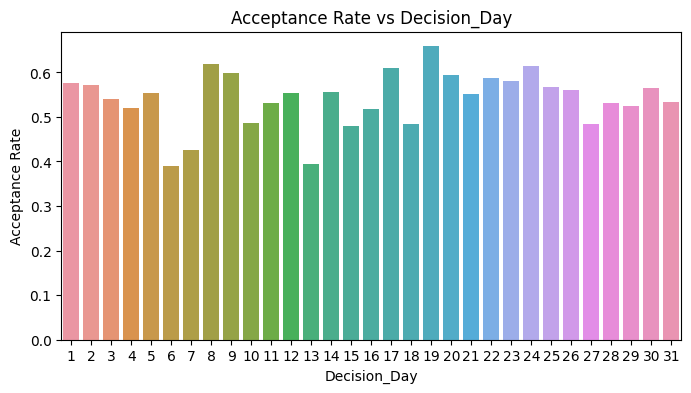

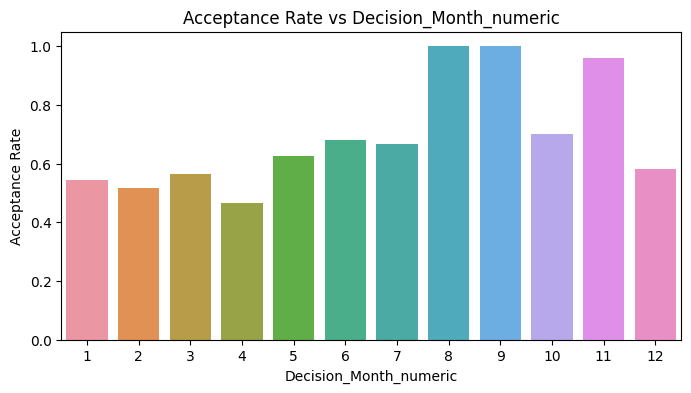

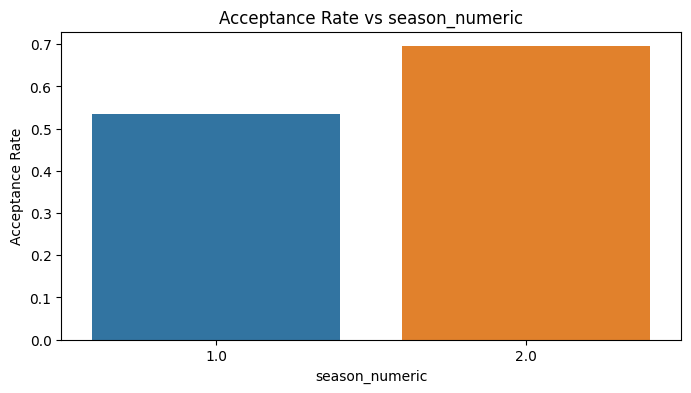

In [349]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

time_features = ['Decision_Day', 'Decision_Month_numeric', 'season_numeric']

corr_matrix = df[time_features + ['Decision']].corr()
print("Correlation between numeric time features and Decision:")
print(corr_matrix['Decision'].sort_values(ascending=False))

for feature in time_features:
    plt.figure(figsize=(8,4))
    sns.barplot(x=feature, y='Decision', data=df, errorbar=None)
    plt.ylabel("Acceptance Rate")
    plt.title(f"Acceptance Rate vs {feature}")
    plt.show()



Correlation analysis of time-related features (`Decision_Day`, `Decision_Month_numeric`, `season_numeric`) with admission outcome showed negligible associations (0.018–0.030). This indicates that day, month, or season of application has minimal effect on decisions. Including these features in modeling could capture spurious trends tied to admission cycles rather than genuine predictors, so they were excluded from the predictive model.


In [350]:

time_features = ['Decision_Day', 'Decision_Month_numeric', 'season_numeric']

df = df.drop(columns=time_features)

df.head(2)


,Decision,GPA,year,FSR SCORE,CPF SCORE,ISR SCORE,QS_Rank,program,Target_Program_Discipline,university_qs_matched,Country/Territory,cleaned_degree_numeric,cleaned_status_numeric,Status_numeric
0,1,3.00,2025.0,53.0,100.0,23.5,49.0,0.000088,0.001446,0.000044,0.001053,1,1.0,1.0
1,1,3.33,2025.0,17.6,79.1,95.5,65.0,0.005041,0.061141,0.000219,0.000527,1,1.0,1.0


In [351]:

df = df.rename(columns={
    'GPA': 'Applicant_GPA',
    'year': 'Decision_Year',
    'FSR SCORE': 'Target_University_FSR_Score',
    'CPF SCORE': 'Target_University_CPF_Score',
    'ISR SCORE': 'Target_University_ISR_Score',
    'QS_Rank': 'Target_University_QS_Rank',
    'university_qs_matched': 'Target_University',
    'Country/Territory': 'Target_Country',
    'cleaned_degree_numeric': 'Target_Degree_Type',
    'cleaned_status_numeric': 'Applicant_Status',
    'program': 'Target_Program',
    'Status_numeric': 'Target_University_Status' 
})

df.head()


,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Program,Target_Program_Discipline,Target_University,Target_Country,Target_Degree_Type,Applicant_Status,Target_University_Status
0,1,3.00,2025.0,53.0,100.0,23.5,49.0,0.000088,0.001446,0.000044,0.001053,1,1.0,1.0
1,1,3.33,2025.0,17.6,79.1,95.5,65.0,0.005041,0.061141,0.000219,0.000527,1,1.0,1.0
2,1,3.85,2025.0,9.5,61.5,53.2,287.0,0.076660,0.077489,0.010300,0.839133,1,2.0,1.0
3,1,3.70,2025.0,100.0,88.6,93.1,6.0,0.000044,0.000307,0.007013,0.042082,1,2.0,1.0
4,0,3.94,2025.0,97.3,78.1,92.8,13.0,0.000351,0.061141,0.021038,0.839133,1,2.0,2.0


In [352]:
df.head(2)

,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Program,Target_Program_Discipline,Target_University,Target_Country,Target_Degree_Type,Applicant_Status,Target_University_Status
0,1,3.00,2025.0,53.0,100.0,23.5,49.0,0.000088,0.001446,0.000044,0.001053,1,1.0,1.0
1,1,3.33,2025.0,17.6,79.1,95.5,65.0,0.005041,0.061141,0.000219,0.000527,1,1.0,1.0


In [353]:


import numpy as np

decode_cols = {
    'Target_Program': 'program',
    'Target_Program_Discipline': 'Target_Program_Discipline',
    'Target_University': 'university_qs_matched',
    'Target_Country': 'Country/Territory'
}

def decode_freq_value(encoded_val, freq_dict):
    """
    Decode a frequency-encoded value by nearest match.
    """
    if pd.isna(encoded_val):
        return np.nan
  
    return min(
        freq_dict.items(),
        key=lambda x: abs(x[1] - encoded_val)
    )[0]

for df_col, mapping_key in decode_cols.items():
    if df_col in df.columns and mapping_key in freq_mappings:
        df[df_col] = df[df_col].apply(
            lambda x: decode_freq_value(x, freq_mappings[mapping_key])
        )

df.head()


,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Program,Target_Program_Discipline,Target_University,Target_Country,Target_Degree_Type,Applicant_Status,Target_University_Status
0,1,3.00,2025.0,53.0,100.0,23.5,49.0,public policy management,business management,Maxwell School Of Citizenship And Public Affairs,China (Mainland),1,1.0,1.0
1,1,3.33,2025.0,17.6,79.1,95.5,65.0,geography,science,lausanne,New Zealand,1,1.0,1.0
2,1,3.85,2025.0,9.5,61.5,53.2,287.0,computer science,computer science,University of Arizona,United States of America,1,2.0,1.0
3,1,3.70,2025.0,100.0,88.6,93.1,6.0,food and resource economic,paleontology,University of Cambridge,United Kingdom,1,2.0,1.0
4,0,3.94,2025.0,97.3,78.1,92.8,13.0,film studie,science,University of Chicago,United States of America,1,2.0,2.0


final check for the remaining valuable colomns to get the most clean and accurate data set later used in recommandation system 

In [354]:
import pandas as pd

unique_disciplines = df['Target_Program_Discipline'].dropna().unique()

print(f"Total unique program disciplines: {len(unique_disciplines)}\n")

for discipline in sorted(unique_disciplines):
    programs_in_discipline = df[df['Target_Program_Discipline'] == discipline]['Target_Program'].dropna().unique()
    programs_in_discipline = sorted(programs_in_discipline)
    print(f"Discipline: {discipline} ({len(programs_in_discipline)} programs)")
    for i, prog in enumerate(programs_in_discipline, start=1):
        print(f"  {i}. {prog}")
    print("-" * 50)


Total unique program disciplines: 95

Discipline: Asian studies (4 programs)
  1. east asian studie
  2. education policy and leadership
  3. food and resource economic
  4. systems engineer
--------------------------------------------------
Discipline: Earth science (5 programs)
  1. applied statistic
  2. education policy and leadership
  3. food and resource economic
  4. public policy management
  5. school counsel
--------------------------------------------------
Discipline: European studies (5 programs)
  1. audiology
  2. biomedical data science
  3. food and resource economic
  4. public policy management
  5. systems engineer
--------------------------------------------------
Discipline: Geisteswissenschaften (5 programs)
  1. biomedical data science
  2. english
  3. food and resource economic
  4. musicology
  5. public policy management
--------------------------------------------------
Discipline: Germanic philology (5 programs)
  1. education policy and leadership
  2. f

In [355]:

unique_programs = df['Target_Program'].unique()

print(unique_programs)

print(sorted(unique_programs))


['public policy management' 'geography' 'computer science'
 'food and resource economic' 'film studie' 'curriculum and instruc'
 'systems engineer' 'international affair' 'history of art' 'Physics'
 'astronomy' 'chemistry' 'education policy and leadership'
 'Biomedical Engineering' 'biomedical science' 'social welfare'
 'learning science' 'Physics & Astronomy' 'Biology'
 'Mechanical Engineering' 'regional plann' 'clinical psychology'
 'Electrical & Computer Engineering' 'public affair' 'urban plann'
 'Urban & Regional Planning' 'Communication Sciences & Disorders' 'nurs'
 'architecture' 'Mathematics' 'art history' 'sociology'
 'biological anthropology' 'Counseling Psychology' 'Robotics'
 'public policy' 'Materials Science & Engineering' 'school counsel'
 'economic' 'political science' 'biomedical data science'
 'Speech-Language Pathology' 'psychology' 'public health' 'english'
 'linguistic' 'Communication' 'music composi'
 'Clinical Mental Health Counseling' 'audiology' 'anthropology'


In [356]:
import pandas as pd

program_correction_map = {
  
    "city and regional plann": "Urban & Regional Planning",
    "city plann": "Urban & Regional Planning",
    "urban and regional plann": "Urban & Regional Planning",
    "regional plann": "Urban & Regional Planning",
    "urban plann": "Urban & Regional Planning",

    "speech language pathology": "Speech-Language Pathology",
    "speech pathology": "Speech-Language Pathology",
    "clinical mental health counsel": "Clinical Mental Health Counseling",
    "mental health counsel": "Clinical Mental Health Counseling",
    "school counsel": "School Counseling",
    "counseling psychology": "Counseling Psychology",
    "social psychology": "Social Psychology",
    "cognitive psychology": "Cognitive Psychology",
    "industrial organizational psychology": "Industrial-Organizational Psychology",

    "biological science": "Biology",
    "biology": "Biology",
    "mcdb": "Cell and Molecular Biology",
    "biochemistry and molecular biology": "Biochemistry & Molecular Biology",
    "bioinformatic": "Biomedical Data Science",
    "biomedical data science": "Biomedical Data Science",
    "biomedical science": "Biomedical Science",
    "cell and molecular biology": "Cell and Molecular Biology",
    "microbiology": "Microbiology",
    "immunology and molecular pathogenesis imp": "Immunology and Molecular Pathogenesis",
    "computational biology": "Computational Biology",
    "ecology": "Ecology",
    "biological anthropology": "Biological Anthropology",
    "sociocultural anthropology": "Sociocultural Anthropology",

    "communica": "Communication",
    "strategic communica": "Strategic Communication",
    "communication sciences and disorder": "Communication Sciences & Disorders",
    "modern culture and media studie": "Modern Culture & Media Studies",
    "curriculum and instruc": "Curriculum and Instruction",
    "learning science": "Learning Science",

    "religious studie": "Religious Studies",
    "theatre arts and performance studie": "Theatre Arts & Performance Studies",
    "english and comparative literature": "English & Comparative Literature",
    "english": "English",
    "art history": "Art History",
    "history of art": "History of Art",
    "film studie": "Film Studies",
    "music composi": "Music Composition",
    "musicology": "Musicology",
    "classical archaeology": "Classical Archaeology",
    "classic": "Classics",
    "east asian studie": "East Asian Studies",
    "east asian languages and culture": "East Asian Languages and Culture",
    "linguistic": "Linguistics",
    "philosophy": "Philosophy",
    "comparative literature": "Comparative Literature",
    "american studie": "American Studies",
    "anthropology": "Anthropology",
    "architecture": "Architecture",
    "astronomy": "Astronomy",
    "audiology": "Audiology",
    "chemistry": "Chemistry",
    "epidemiology": "Epidemiology",
    "geography": "Geography",
    "history": "History",
    "neuroscience": "Neuroscience",
    "organizational behavior": "Organizational Behavior",
    "public health": "Public Health",
    "sociology": "Sociology",

    "educa": "Education",
    "education policy": "Education Policy",
    "education policy and leadership": "Education Policy & Leadership",

    "applied mathematic": "Applied Mathematics",
    "mathematic": "Mathematics",
    "pure mathematic": "Pure Mathematics",
    "statistic": "Statistics",
    "biostatistic": "Biostatistics",
    "applied statistic": "Applied Statistics",
    "economic": "Economics",
    "agricultural economic": "Agricultural Economics",
    "food and resource economic": "Food and Resource Economics",
    "finance": "Finance",
    "management science and engineer": "Management Science and Engineering",

    "applied physic": "Applied Physics",
    "physic": "Physics",
    "physics and astronomy": "Physics & Astronomy",
    "aerospace engineer": "Aerospace Engineering",
    "bioengineer": "Bioengineering",
    "biomedical engineer": "Biomedical Engineering",
    "chemical and biomolecular engineer": "Chemical & Biomolecular Engineering",
    "chemical and biological engineer": "Chemical & Biomolecular Engineering",
    "chemical engineer": "Chemical Engineering",
    "electrical and computer engineer": "Electrical & Computer Engineering",
    "electrical engineer": "Electrical Engineering",
    "mechanical engineer": "Mechanical Engineering",
    "robotic": "Robotics",
    "systems engineer": "Systems Engineering",
    "civil engineer": "Civil Engineering",
    "materials science": "Materials Science",
    "materials science and engineer": "Materials Science & Engineering",
    "computer science": "Computer Science",
    "data science": "Data Science",
    "information science": "Information Science",
    "human computer interac": "Human-Computer Interaction",
    "robotics": "Robotics",

    "government": "Government",
    "international affair": "International Affairs",
    "nurs": "Nursing",
    "public administra": "Public Administration",
    "public affair": "Public Affairs",
    "public policy": "Public Policy",
    "public policy management": "Public Policy & Management",
    "social welfare": "Social Welfare",
    "social work": "Social Work",
    "psychology": "Psychology",
    "clinical psychology": "Clinical Psychology",
    "political science": "Political Science",
}

df['Target_Program'] = df['Target_Program'].replace(program_correction_map)


unique_programs_cleaned = sorted(df['Target_Program'].dropna().astype(str).unique())

print(f"Total unique programs after cleaning: {len(unique_programs_cleaned)}\n")
for i, prog in enumerate(unique_programs_cleaned, start=1):
    print(f"{i}. {prog}")


Total unique programs after cleaning: 93

1. Aerospace Engineering
2. Agricultural Economics
3. American Studies
4. Anthropology
5. Applied Mathematics
6. Applied Physics
7. Applied Statistics
8. Architecture
9. Art History
10. Astronomy
11. Audiology
12. Biological Anthropology
13. Biology
14. Biomedical Data Science
15. Biomedical Engineering
16. Biomedical Science
17. Biostatistics
18. Cell and Molecular Biology
19. Chemical & Biomolecular Engineering
20. Chemical Engineering
21. Chemistry
22. Civil Engineering
23. Classical Archaeology
24. Classics
25. Clinical Mental Health Counseling
26. Clinical Psychology
27. Cognitive Psychology
28. Communication
29. Communication Sciences & Disorders
30. Comparative Literature
31. Computational Biology
32. Computer Science
33. Counseling Psychology
34. Curriculum and Instruction
35. Data Science
36. East Asian Languages and Culture
37. East Asian Studies
38. Ecology
39. Economics
40. Education
41. Education Policy
42. Education Policy & Leade

In [357]:


program_to_discipline = {

    "Computer Science": "Computer Science & Information Systems",
    "Data Science": "Data Science",
    "Information Science": "Computer Science & Information Systems",
    "Human-Computer Interaction": "Computer Science & Information Systems",

    "Mechanical Engineering": "Engineering – Mechanical, Aeronautical & Manufacturing",
    "Aerospace Engineering": "Engineering – Mechanical, Aeronautical & Manufacturing",
    "Robotics": "Engineering – Mechanical, Aeronautical & Manufacturing",
    "Bioengineering": "Biomedical Science",

    "Electrical Engineering": "Engineering – Electrical & Electronic",
    "Electrical & Computer Engineering": "Engineering – Electrical & Electronic",

    "Chemical Engineering": "Engineering – Chemical",
    "Chemical & Biomolecular Engineering": "Engineering – Chemical",
    "Materials Science & Engineering": "Engineering – Chemical",
    "Civil Engineering": "Engineering – Civil & Structural",
    "Systems Engineering": "Engineering – General",

    "Biomedical Engineering": "Biomedical Science",
    "Biomedical Science": "Biomedical Science",
    "Biomedical Data Science": "Biomedical Science",

    "Biology": "Biological Sciences",
    "Cell and Molecular Biology": "Biological Sciences",
    "Computational Biology": "Biological Sciences",
    "Microbiology": "Biological Sciences",
    "Immunology and Molecular Pathogenesis": "Biological Sciences",
    "Neuroscience": "Biological Sciences",
    "Epidemiology": "Biological Sciences",
    "Biostatistics": "Biological Sciences",

    "Public Health": "Medicine",
    "Nursing": "Nursing",
    "Audiology": "Life Sciences & Medicine",
    "Speech-Language Pathology": "Life Sciences & Medicine",
    "Communication Sciences & Disorders": "Life Sciences & Medicine",

    "Physics": "Physics & Astronomy",
    "Physics & Astronomy": "Physics & Astronomy",
    "Astronomy": "Physics & Astronomy",
    "Applied Physics": "Physics & Astronomy",

    "Chemistry": "Chemistry",
    "Ecology": "Environmental Sciences",
    "Geography": "Geography",

    "Mathematics": "Mathematics",
    "Applied Mathematics": "Mathematics",
    "Pure Mathematics": "Mathematics",

    "Statistics": "Statistics & Operational Research",
    "Applied Statistics": "Statistics & Operational Research",

    "Economics": "Economics & Econometrics",
    "Agricultural Economics": "Economics & Econometrics",
    "Food and Resource Economics": "Economics & Econometrics",
    "Finance": "Accounting & Finance",

    "Management Science and Engineering": "Business & Management Studies",
    "Organizational Behavior": "Business & Management Studies",

    "Public Policy": "Politics & International Studies",
    "Public Policy & Management": "Politics & International Studies",
    "Public Affairs": "Politics & International Studies",
    "Public Administration": "Politics & International Studies",
    "Political Science": "Politics & International Studies",
    "International Affairs": "Politics & International Studies",
    "Government": "Politics & International Studies",

    "Sociology": "Sociology",
    "Social Welfare": "Social Work",
    "Social Work": "Social Work",

    "Anthropology": "Anthropology",
    "Biological Anthropology": "Anthropology",
    "Sociocultural Anthropology": "Anthropology",

    "Psychology": "Psychology",
    "Social Psychology": "Psychology",
    "Clinical Psychology": "Psychology",
    "Counseling Psychology": "Psychology",
    "Clinical Mental Health Counseling": "Psychology",
    "Cognitive Psychology": "Psychology",
    "Industrial-Organizational Psychology": "Psychology",

    "English": "English Language & Literature",
    "Linguistics": "Linguistics",
    "Philosophy": "Philosophy",

    "History": "History",
    "History of Art": "History of Art",
    "Art History": "History of Art",

    "Classical Archaeology": "Archaeology",
    "Classics": "Classics & Ancient History",
    "American Studies": "American Studies",
    "Religious Studies": "Religious Studies",
    "Comparative Literature": "Comparative Literature",

    "Film Studies": "Performing Arts",
    "Music Composition": "Music",
    "Musicology": "Music",
    "Modern Culture & Media Studies": "Performing Arts",

    "Education": "Education",
    "Education Policy": "Education",
    "Education Policy & Leadership": "Education",
    "Curriculum and Instruction": "Education",
    "School Counseling": "Education",
    "Learning Science": "Education",

    "Architecture": "Architecture / Built Environment",
    "Urban & Regional Planning": "Architecture / Built Environment",

    "Communication": "Communication & Media Studies",

    "East Asian Studies": "Modern Languages",
    "East Asian Languages and Culture": "Modern Languages",
}

df["Target_Program_clean"] = df["Target_Program"].str.strip()

df["program_discipline"] = df["Target_Program_clean"].map(program_to_discipline)

unmapped = df[df["program_discipline"].isna()]["Target_Program"].unique()
print("Unmapped programs:", unmapped)


Unmapped programs: []


In [358]:
df.drop(columns=["Target_Program_Discipline"], inplace=True)
df = df.rename(columns={"program_discipline": "Target_Program_Discipline"})


In [359]:

df = df.drop(columns=["Target_Program"], errors="ignore")
df = df.rename(columns={"Target_Program_clean": "Target_Program"})


In [360]:
df.head()

,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_University,Target_Country,Target_Degree_Type,Applicant_Status,Target_University_Status,Target_Program,Target_Program_Discipline
0,1,3.00,2025.0,53.0,100.0,23.5,49.0,Maxwell School Of Citizenship And Public Affairs,China (Mainland),1,1.0,1.0,Public Policy & Management,Politics & International Studies
1,1,3.33,2025.0,17.6,79.1,95.5,65.0,lausanne,New Zealand,1,1.0,1.0,Geography,Geography
2,1,3.85,2025.0,9.5,61.5,53.2,287.0,University of Arizona,United States of America,1,2.0,1.0,Computer Science,Computer Science & Information Systems
3,1,3.70,2025.0,100.0,88.6,93.1,6.0,University of Cambridge,United Kingdom,1,2.0,1.0,Food and Resource Economics,Economics & Econometrics
4,0,3.94,2025.0,97.3,78.1,92.8,13.0,University of Chicago,United States of America,1,2.0,2.0,Film Studies,Performing Arts


In [361]:
import pandas as pd
import pickle


cat_cols = ['Target_Program', 'Target_Program_Discipline', 'Target_University', 'Target_Country']

freq_mappings = {}

for col in cat_cols:
    freq = df[col].value_counts(normalize=True)  
    df[col + '_freq'] = df[col].map(freq)
    freq_mappings[col] = freq.to_dict() 

save_path = '/Users/melina/Downloads/freq_mappingsF.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(freq_mappings, f)

print("Frequency encoding applied and mappings saved to:", save_path)
df.head(5)

Frequency encoding applied and mappings saved to: /Users/melina/Downloads/freq_mappingsF.pkl


,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_University,Target_Country,Target_Degree_Type,Applicant_Status,Target_University_Status,Target_Program,Target_Program_Discipline,Target_Program_freq,Target_Program_Discipline_freq,Target_University_freq,Target_Country_freq
0,1,3.00,2025.0,53.0,100.0,23.5,49.0,Maxwell School Of Citizenship And Public Affairs,China (Mainland),1,1.0,1.0,Public Policy & Management,Politics & International Studies,0.027231,0.070154,0.005154,0.001077
1,1,3.33,2025.0,17.6,79.1,95.5,65.0,lausanne,New Zealand,1,1.0,1.0,Geography,Geography,0.010385,0.010385,0.003385,0.001077
2,1,3.85,2025.0,9.5,61.5,53.2,287.0,University of Arizona,United States of America,1,2.0,1.0,Computer Science,Computer Science & Information Systems,0.083308,0.087077,0.010000,0.845308
3,1,3.70,2025.0,100.0,88.6,93.1,6.0,University of Cambridge,United Kingdom,1,2.0,1.0,Food and Resource Economics,Economics & Econometrics,0.082231,0.139077,0.005308,0.035846
4,0,3.94,2025.0,97.3,78.1,92.8,13.0,University of Chicago,United States of America,1,2.0,2.0,Film Studies,Performing Arts,0.006308,0.006308,0.022154,0.845308


In [362]:
df = df.drop(columns=cat_cols)
for col in cat_cols:
    df.rename(columns={col + '_freq': col}, inplace=True)


In [363]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import pickle


numeric_features = [
    'Applicant_GPA',
    'Target_University_FSR_Score',
    'Target_University_CPF_Score',
    'Target_University_ISR_Score',
    'Target_University_QS_Rank',
    'Decision_Year' 
]


scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])


with open('/Users/melina/Downloads/scalerF.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Numeric features scaled using StandardScaler and scaler saved to scaler.pkl")
print(df[numeric_features].describe())


Numeric features scaled using StandardScaler and scaler saved to scaler.pkl
       Applicant_GPA  Target_University_FSR_Score  \
count   1.300000e+04                 1.300000e+04   
mean    2.399448e-16                -9.073084e-17   
std     1.000038e+00                 1.000038e+00   
min    -1.164503e+01                -1.626338e+00   
25%    -3.165785e-01                -1.067615e+00   
50%     2.103261e-01                -1.172096e-01   
75%     6.494133e-01                 1.175918e+00   
max     1.088501e+00                 1.224878e+00   

       Target_University_CPF_Score  Target_University_ISR_Score  \
count                 1.300000e+04                 1.300000e+04   
mean                 -2.585282e-16                 2.186285e-18   
std                   1.000038e+00                 1.000038e+00   
min                  -2.270392e+00                -1.820103e+00   
25%                  -9.093901e-01                -1.040783e+00   
50%                   6.905965e-02          

In [364]:
import pandas as pd

df.to_csv("/Users/melina/Downloads/dfforbaseline.csv", index=False)

print("DataFrame saved as 'dfforbaseline.csv' in Downloads.")

DataFrame saved as 'dfforbaseline.csv' in Downloads.
